In [38]:
import polars as pl
import torch
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.linear_model import Lasso
import numpy as np
from amaretto_mlp import *
from utils_b import *
from autoencoder import *
from explanation import *

#%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# 1. Data & model preperatiom

In [20]:
pl.Config.set_tbl_cols(150) 

polars.config.Config

In [3]:
df = pl.read_parquet("amaretto_transformed_scaled.pq")
df = df.with_columns(((pl.col('hour') >= 2) & (pl.col('hour') < 5)).alias('unusual_hour'))
df_train, df_val, df_test = split_data(df)

#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime']
#columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute']
columns_to_drop = ['id', 'Anomaly', 'Anomaly_bin', 'Originator', 'datetime', 'day_of_week', 'day_of_month', 'hour', 'minute', 'day_of_month_cos', 'minute_cos', 'day_of_month_sin', 'minute_sin']


target_column = 'Anomaly'
y_train = df_train.select(target_column).to_numpy().flatten()
df_train = df_train.drop(columns_to_drop)
X_train = df_train.to_numpy()
y_val = df_val.select(target_column).to_numpy().flatten()
X_val = df_val.drop(columns_to_drop).to_numpy()
y_test = df_test.select(target_column).to_numpy().flatten()
X_test = df_test.drop(columns_to_drop).to_numpy()

train_dataset = AmarettoDataset(X_train, y_train)
val_dataset = AmarettoDataset(X_val, y_val)
test_dataset = AmarettoDataset(X_test, y_test)
feature_names = df_train.columns
print(X_train.shape)
print(X_test.shape)

(24451934, 118)
(2765755, 118)


In [4]:
train_loader = DataLoader(train_dataset, batch_size=512, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=512, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=512, num_workers=2)
input_dim = X_train.shape[1]
df_train, df_val, df_test = split_data(df)
print(len(train_loader))

47758


In [5]:
model = CombinedModel(input_dim=X_train.shape[1], hidden_layers=[64, 64], latent_dim=16, num_classes=6)
model.load_state_dict(torch.load("model_combined_best.pth"))
print(model)

CombinedModel(
  (encoder): Encoder(
    (network): Sequential(
      (0): Linear(in_features=118, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=16, bias=True)
    )
  )
  (decoder): Decoder(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=118, bias=True)
    )
  )
  (classifier): Classifier(
    (network): Sequential(
      (0): Linear(in_features=16, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=6, bias=True)
    )
  )
)


In [6]:
model.eval()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_train, z_train = model(X_train_tensor)
    y_pred_train = torch.argmax(y_pred_train, dim=1)
y_pred_train = y_pred_train.cpu().detach().numpy()
print(y_pred_train.shape)
z_train = z_train.cpu().numpy()
print(z_train.shape)

(24451934,)
(24451934, 16)


In [7]:
print(classification_report(y_train, y_pred_train, digits=4))

              precision    recall  f1-score   support

           0     0.9998    0.9978    0.9988  24384055
           1     0.2560    0.6335    0.3646      4837
           2     0.6635    0.8484    0.7447      2078
           3     0.5482    0.9609    0.6981      9758
           4     0.5338    0.7452    0.6220     26386
           5     0.2833    0.5393    0.3715     24820

    accuracy                         0.9969  24451934
   macro avg     0.5474    0.7875    0.6333  24451934
weighted avg     0.9982    0.9969    0.9975  24451934



In [8]:
print(confusion_matrix(y_train, y_pred_train))

[[24330063     7971      726     7608     8023    29664]
 [     501     3064       35       27      904      306]
 [      47      235     1763       33        0        0]
 [     260        3       97     9376       17        5]
 [    2509      262       24       42    19663     3886]
 [    2742      435       12       16     8230    13385]]


In [9]:
model.eval()
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
with torch.no_grad():
    _, y_pred_test, z_test = model(X_test_tensor)
    y_pred_test = torch.argmax(y_pred_test, dim=1)
y_pred_test = y_pred_test.cpu().detach().numpy()
print(y_pred_test.shape)
z_test = z_test.cpu().numpy()
print(z_test.shape)

(2765755,)
(2765755, 16)


In [10]:
df_test = df_test.with_columns(pl.Series("Model Prediction", y_pred_test))
df_test = df_test.select(["Model Prediction", *df_test.columns[:-1]])  
df_test = df_test.with_row_index(name="index")
df_test

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
0,5,27025095,2019-03-18 00:00:01,"""Client_023""",0,0,0.507711,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,0,1,18,0,0,false,1.771247,1.252211,1.039728,0.94558,-2.511988,1.660603,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-1.175981,-1.290214,-0.000167,0.000056,0.71708,1.365456,0.513469,-1.287407,0.279149,3.620574,0.147873,1.40623,-284.418707,-594.740725,-701.775893,-0.891973,-40.7518

In [11]:
df_train = df_train.with_columns(pl.Series("Model Prediction", y_pred_train))
df_train = df_train.select(["Model Prediction", *df_train.columns[:-1]])  
df_train = df_train.with_row_index(name="index")
df_train

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
0,3,151925,2019-01-01 00:00:03,"""Client_259""",0,0,0.392679,0,1,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,2,1,0,0,false,-5.176871,-4.005506,-3.292225,-2.835853,-2.511988,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-0.000079,-0.000208,-0.000167,0.000056,-0.811648,0.879612,0.087694,1.476385,0.279149,3.620574,0.147873,1.40623,-284.418707,-594.740725,-701.775893,-1850.737809,-

In [12]:
print(classification_report(y_test, y_pred_test, digits=4))

              precision    recall  f1-score   support

           0     0.9998    0.9986    0.9992   2759074
           1     0.3958    0.6858    0.5019       576
           2     0.6084    0.9611    0.7451       257
           3     0.6735    0.9813    0.7988      1175
           4     0.3874    0.7531    0.5117      2228
           5     0.4177    0.4597    0.4377      2445

    accuracy                         0.9978   2765755
   macro avg     0.5804    0.8066    0.6657   2765755
weighted avg     0.9985    0.9978    0.9981   2765755



In [13]:
print(confusion_matrix(y_test, y_pred_test))

[[2755103     518     152     545    1552    1204]
 [     55     395       1       0     109      16]
 [      4       4     247       2       0       0]
 [     16       0       1    1153       5       0]
 [    160      28       4      11    1678     347]
 [    279      53       1       1     987    1124]]


In [14]:
mask_correct_preds = (y_test[y_test != 0] == y_pred_test[y_test != 0])
mask_wrong_preds = (y_test[y_test != 0] != y_pred_test[y_test != 0])
print(mask_correct_preds.sum())
print(mask_wrong_preds.sum())

4597
2084


In [15]:
df_correct_preds = df_test.filter((pl.col("Anomaly") != 0))
print(df_correct_preds.height)
df_correct_preds = df_correct_preds.filter(mask_correct_preds)
df_wrong_preds = df_test.filter((pl.col("Anomaly") != 0))
print(df_wrong_preds.height)
df_wrong_preds = df_wrong_preds.filter(mask_wrong_preds)
print(df_correct_preds.height)
print(df_wrong_preds.height)

6681
6681
4597
2084


# 2. Explanations on input space

In [23]:
X_train_n = X_train[y_pred_train == 0]
z_train_n = z_train[y_pred_train == 0]
y_train_n = y_pred_train[y_pred_train == 0]
print(X_train_n.shape)
print(z_train_n.shape)
print(y_train_n.shape)



(24336122, 118)
(24336122, 16)
(24336122,)


## 2.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  


In [274]:
anomaly_type = 1
#idx = 8357
idx = 38329

In [275]:
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(11970, 118)
(11970,)


In [449]:
# z_train_n = z_train[y_train == 0]
# y_train_n = y_pred_train[y_pred_train == 0]
# z_train_a = z_train[y_pred_train == anomaly_type]
# y_train_a = y_pred_train[y_pred_train == anomaly_type]

In [276]:
# x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

# model.encoder.eval()
# test_transaction_latent = model.encoder(x)
# test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
# test_transaction_latent = test_transaction_latent.reshape(1, -1)
# test_transaction_latent.shape

(1, 118)
[[-1.44874071  0.          1.          0.          1.          0.        ]]
1
1


In [277]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
38329,1,26944892,2019-03-18 08:01:16,"""Client_389""",1,1,-1.448741,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,18,8,1,false,2.054952,1.690853,1.400966,1.251966,1.166733,-0.669069,-0.284955,-0.112912,0.0,0.0,1.037127,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.549258,-0.000208,0.646075,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,0.000044,1.413977,0.344561,0.199322,0.2127,-0.933059,0.123479,-2.250

In [278]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [25]:
#df_train.filter(pl.col('Anomaly') == 0)[indices_n.flatten().tolist()]
#df_train.filter(pl.col('Anomaly') == 1)[indices_a.flatten().tolist()]

In [279]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01)

In [280]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[  0  25  23  22 116  35  94  30  61  75]
num of non-zero features: 19
amount_log: -0.21986987138746705
Product Class_Cash in / out (withdrawal), Security in / out: 0.17702574820899486
Product Type_SimpleTransfer: 0.14416040396712718
Product Type_Repo: -0.12792514744917396
Currency_freq_originator: 0.10790368290914165
originator_index_timestamp_diff_5: -0.10468893274116396
rolling_max_originator_7d: -0.06385439139857292
is_rounded: 0.05720226454927488
rolling_mean_24h: -0.055843821000926004
rolling_min_1h: 0.04399060608708936


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


2100
24384055
2100


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
1


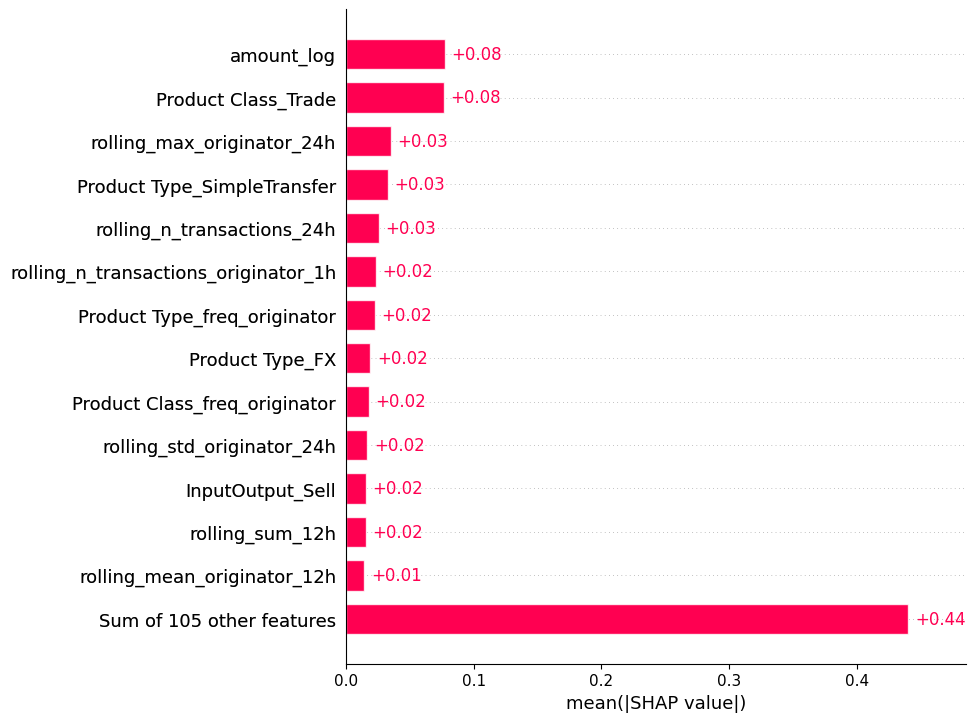

Saved SHAP plots for class 1 to output/shap_plots/
SHAP explanations generated and saved.


In [297]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_CM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
1


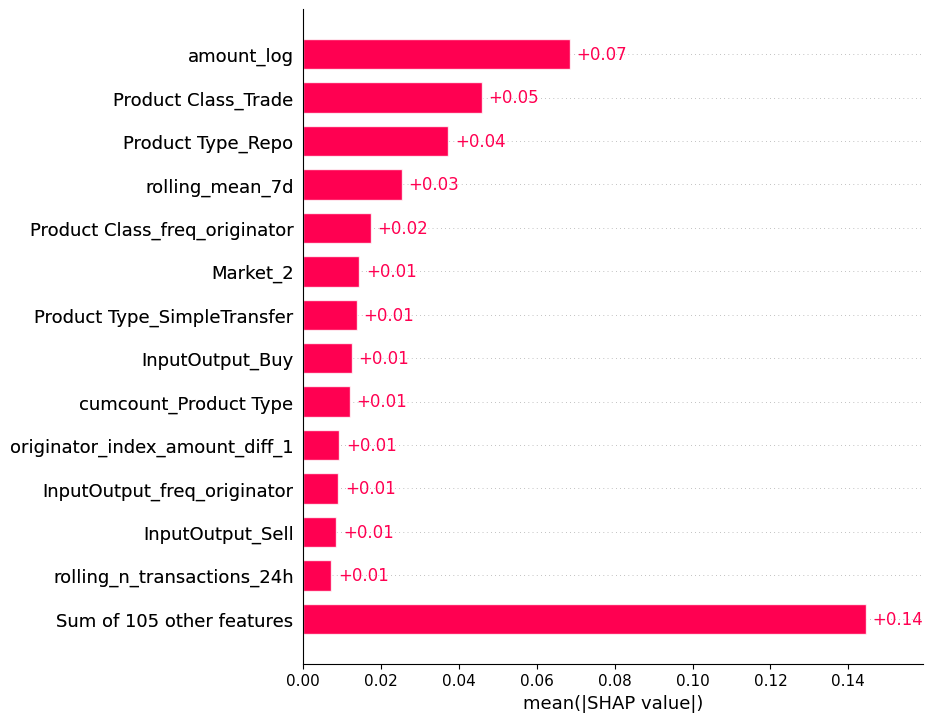

Saved SHAP plots for class 1 to output/shap_plots/
SHAP explanations generated and saved.


In [296]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')

In [25]:
imp_features = [feature_names[idx] for idx in sorted_importance]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['amount_log', 'Product Class_Cash in / out (withdrawal), Security in / out', 'Product Type_SimpleTransfer', 'Product Type_Repo', 'Currency_freq_originator', 'originator_index_timestamp_diff_5', 'rolling_max_originator_7d', 'is_rounded', 'rolling_mean_24h', 'rolling_min_1h']


amount_log,"Product Class_Cash in / out (withdrawal), Security in / out",Product Type_SimpleTransfer,Product Type_Repo,Currency_freq_originator,originator_index_timestamp_diff_5,rolling_max_originator_7d,is_rounded,rolling_mean_24h,rolling_min_1h
f64,u8,u8,u8,f64,f64,f64,bool,f64,f64
-1.448741,1,1,0,-1.602753,1.166733,0.236758,false,0.2127,0.354526


In [26]:
y_pred = lasso_classifier.predict(x.reshape(1, -1))
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[0.49983937]
R squared training set 0.8598427783060791


In [27]:
lasso_classifier = Lasso(alpha=0.05)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[  0 116  23 115  22 112  75  94 111 108]
num of non-zero features: 8
amount_log: -0.21023178456333913
Currency_freq_originator: 0.12919019410441543
Product Type_SimpleTransfer: 0.0886599207848995
Product Class_freq_originator: -0.06484219121880014
Product Type_Repo: -0.06226252364859653
InputOutput_freq_originator: -0.024060356763416554
rolling_min_1h: 0.020035186440123587
rolling_max_originator_7d: -0.01182196259420108
cumcount_Currency: -0.0
cumcount_Market: -0.0


## 2.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [298]:
anomaly_type = 2
idx = 2762998
#idx = 8891

In [299]:
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(2657, 118)
(2657,)


In [300]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 118)
[[-0.15372607  0.          1.          0.          0.          1.        ]]
2
2


In [68]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
8891,2,27013699,2019-03-18 07:08:31,"""Client_066""",2,1,-0.190208,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,7,8,true,2.694246,1.938714,1.604807,1.429491,1.326428,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.89806,-0.000208,-0.000167,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.946266,1.050736,-1.469272,-3.17115,-3.764227,-0.91711,-3.313611,-

In [301]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [302]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01)

In [303]:
#idx = 2762998
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 30  25 115  52 114   1 112  56  78  31]
num of non-zero features: 22
is_rounded: 0.9114439350973315
Product Class_Cash in / out (withdrawal), Security in / out: 0.5964396349203723
Product Class_freq_originator: 0.18382685232148818
market_index_amount_diff_1: 0.1289961605185301
Product Type_freq_originator: 0.11328421212743527
InputOutput_Buy: -0.0951366664703487
InputOutput_freq_originator: 0.09179075251562506
day_of_week_cos: -0.08498780450270951
rolling_min_7d: -0.0789474741298009
originator_index_timestamp_diff_1: -0.07833886454663339


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


2100
24384055
2100


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
2


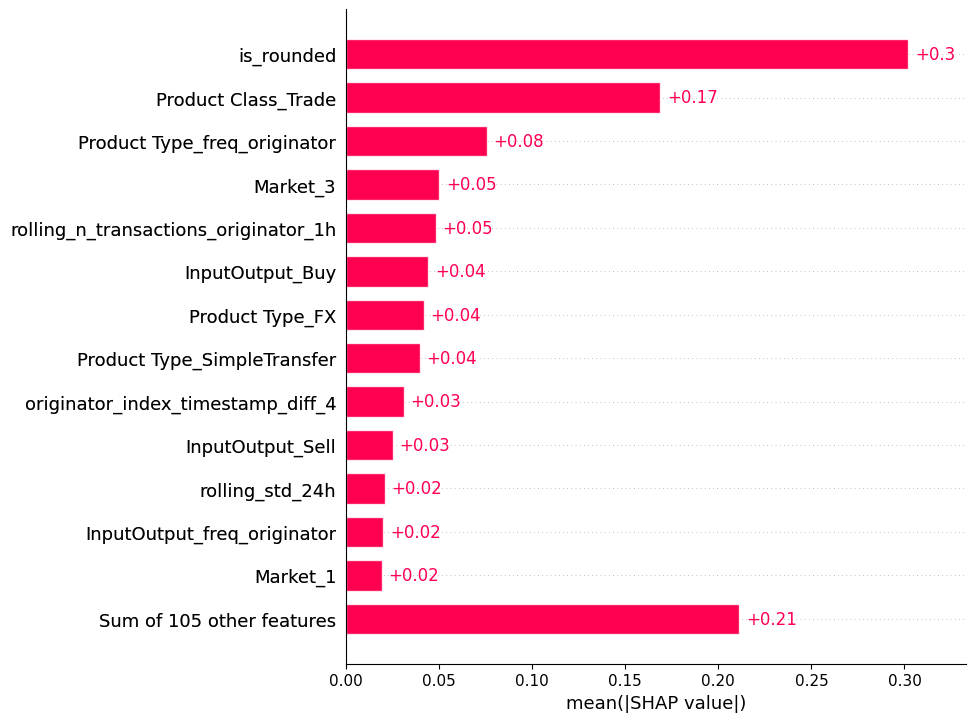

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [304]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_CM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
2


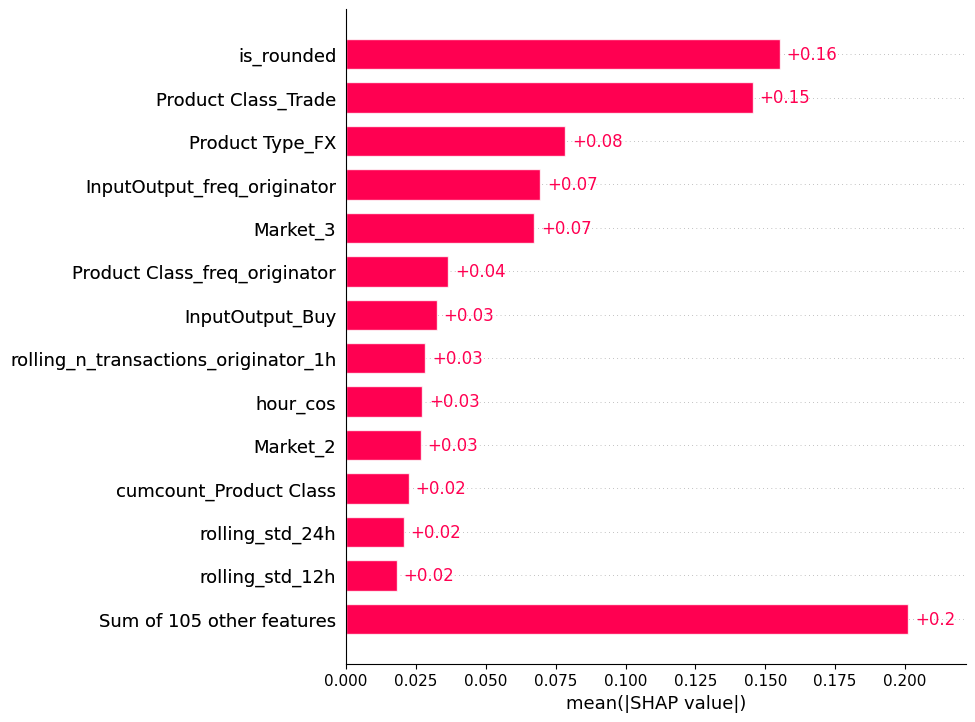

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [305]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')


In [74]:
# 8891, # k = 21, #alpha=0.01
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25  63  41 112  30  79  77  27 109 110]
num of non-zero features: 8
Product Class_Cash in / out (withdrawal), Security in / out: 1.9874958666746703
rolling_sum_1h: 0.0014410673450524305
product_type_index_timestamp_diff_1: 0.0008635023662354762
InputOutput_freq_originator: 0.0007342879603592788
is_rounded: 0.0006962445213333058
rolling_n_transactions_1h: 0.00010707328174031953
rolling_min_24h: -3.8452187782518644e-05
Product Class_Trade: -2.5434019969493096e-14
cumcount_Product Type: -0.0
cumcount_Product Class: -0.0


In [75]:
# 8891, # k = 210 #alpha=0.01
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=210)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

(420, 118)
(420,)
[ 30   1  25  23  93   0  65 108  76  77]
num of non-zero features: 22
is_rounded: 0.8685373295083717
InputOutput_Buy: -0.2689412509531235
Product Class_Cash in / out (withdrawal), Security in / out: 0.2648118403729789
Product Type_SimpleTransfer: 0.07923792561866698
rolling_max_originator_24h: -0.0737117664260806
amount_log: -0.05433003469889601
rolling_sum_24h: 0.04747998338724233
cumcount_Market: -0.04423280599655343
rolling_min_12h: -0.03553188641471599
rolling_min_24h: -0.026932989837985644


Using 420 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
2


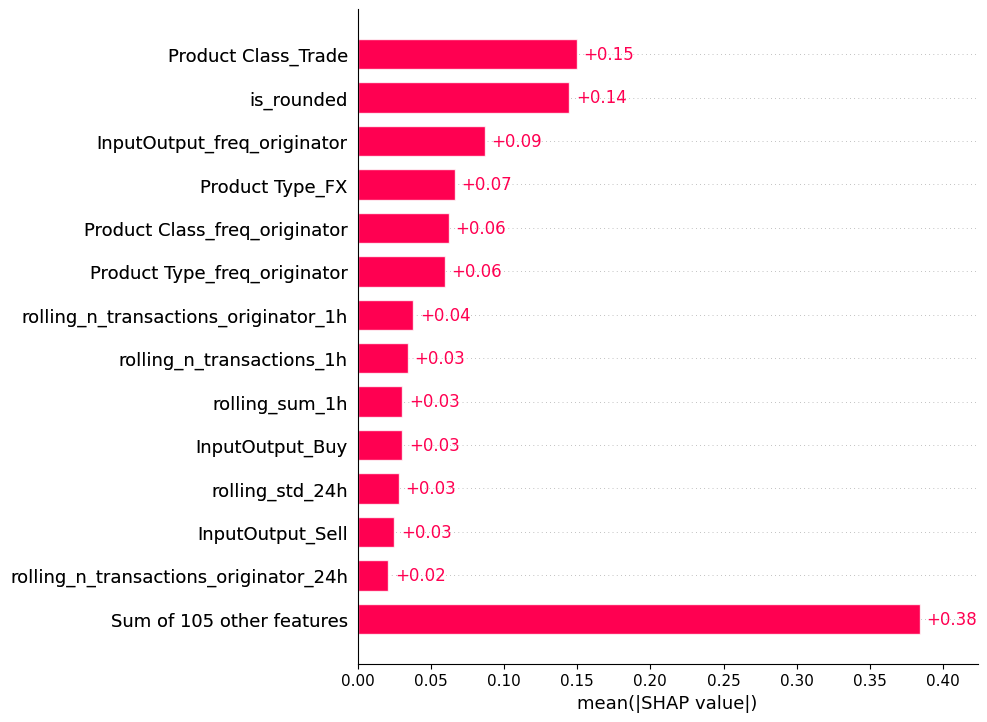

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [76]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso_another')

In [417]:
imp_features = [feature_names[idx] for idx in sorted_importance]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['is_rounded', 'InputOutput_freq_originator', 'Product Class_freq_originator', 'unusual_hour', 'Product Type_freq_originator', 'Market_freq_originator', 'cumcount_Currency', 'cumcount_Product Class', 'cumcount_Product Type', 'cumcount_Market']


is_rounded,InputOutput_freq_originator,Product Class_freq_originator,unusual_hour,Product Type_freq_originator,Market_freq_originator,cumcount_Currency,cumcount_Product Class,cumcount_Product Type,cumcount_Market
bool,f64,f64,bool,f64,f64,f64,f64,f64,f64
true,2.639691,-0.499056,false,1.495638,-1.722951,0.069083,-0.138752,0.445416,-0.798103


In [77]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[1.42788346]
R squared training set 0.9722511029493373


## 2.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [314]:
anomaly_type = 3
idx = 1165
#idx = 2191351
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(17102, 118)
(17102,)


In [315]:
#df_correct_preds.filter((pl.col("Anomaly") == 3))

In [316]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 118)
[[0.51730322 0.         1.         0.         1.         0.        ]]
3
3


In [317]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
1165,3,27021018,2019-03-18 02:03:40,"""Client_212""",3,1,0.517303,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,2,3,false,2.277038,1.623655,1.345376,1.204335,1.123912,-0.669069,-0.284955,-0.112912,0.0,0.0,1.036349,-0.917766,-0.698787,-0.576665,-0.484611,2.410612,-0.183119,-0.071133,0.0,0.0,-1.297503,-0.000208,1.22626,2.510179,0.71708,1.365456,0.513469,-1.287407,-0.415434,3.620574,-0.293992,1.383074,-8.062019,-2.551143,-3.032662,-0.88602,-7.795076,-7

In [92]:
#idx = 1165
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

(42, 118)
(42,)
[ 25  13 114 112  75  78  58  23  97  54]
num of non-zero features: 29
Product Class_Cash in / out (withdrawal), Security in / out: 0.7827086352208266
Product Type_FX: -0.6757102446906595
Product Type_freq_originator: 0.6474026209255213
InputOutput_freq_originator: 0.3139014288012042
rolling_min_1h: -0.30435852767379173
rolling_min_7d: 0.2603986668568083
hour_cos: 0.2250879224071435
Product Type_SimpleTransfer: 0.18984259782294585
rolling_min_originator_24h: -0.18143225274264838
product_class_index_amount_diff_1: 0.15226465756110794


In [ ]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso_another')

In [318]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=210)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

(420, 118)
(420,)
[ 23  25   1 117 114 102  99 112  42  31]
num of non-zero features: 33
Product Type_SimpleTransfer: 0.804394794965323
Product Class_Cash in / out (withdrawal), Security in / out: 0.7133668382027525
InputOutput_Buy: -0.4952911455110718
unusual_hour: 0.2822219566845097
Product Type_freq_originator: 0.17079497876998662
rolling_sum_originator_7d: -0.16444975344841758
rolling_sum_originator_1h: 0.12146909744559228
InputOutput_freq_originator: 0.10370441119739855
product_type_index_timestamp_diff_2: 0.08438291847268338
originator_index_timestamp_diff_1: 0.07736709049167027


[ 4837  2078  9758 26386 24820]


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


2100
24384055
2100


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
3


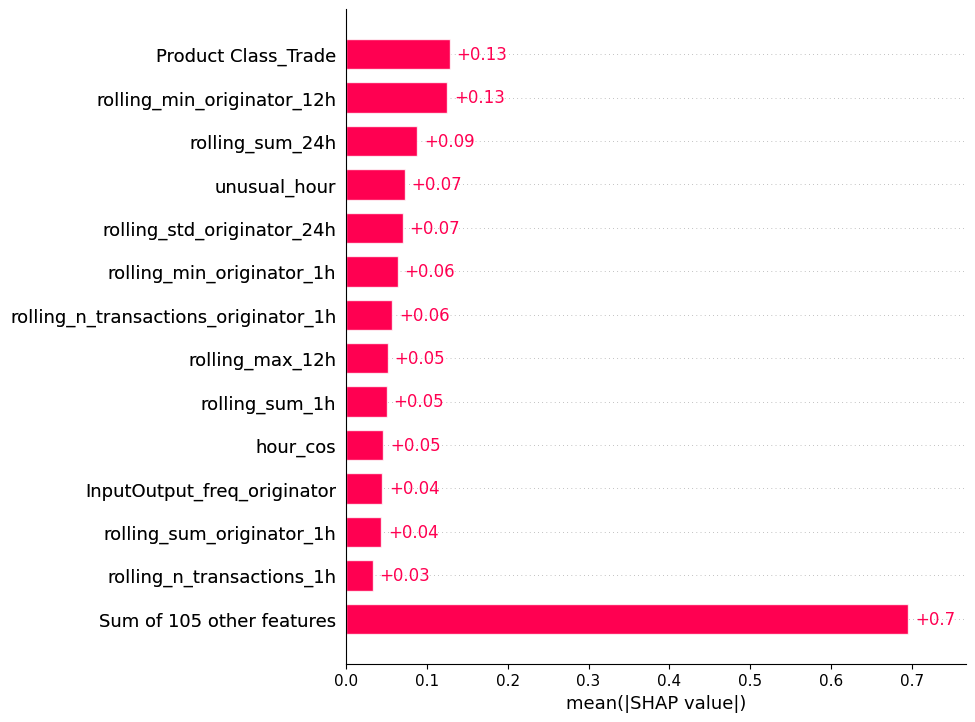

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [310]:
X_train_shap, _, _ = sample_data(X_train, y_train, n_samples=3000, anomaly_ratio=0.3, random_seed=42)
get_shap_explanations_mlp_class(model, X_train_shap, x.reshape(1, -1), feature_names, filename='figs/shap_plots/shap_CM')

Using 420 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
3


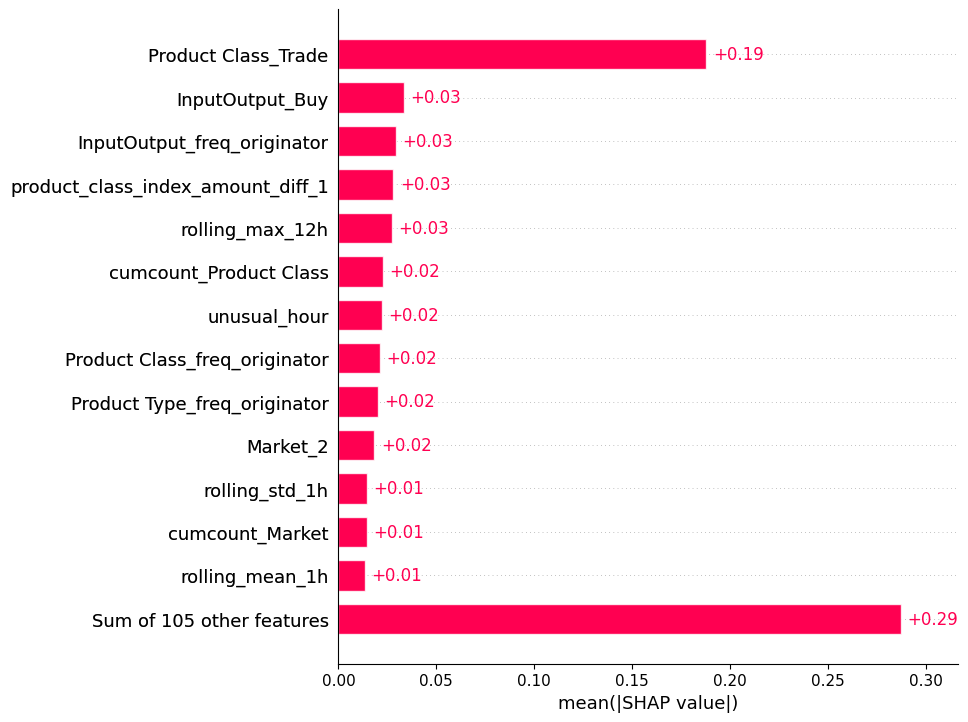

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [319]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')

In [97]:
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['Product Type_SimpleTransfer', 'Product Class_Cash in / out (withdrawal), Security in / out', 'InputOutput_Buy', 'unusual_hour', 'Product Type_freq_originator', 'rolling_sum_originator_7d', 'rolling_sum_originator_1h', 'InputOutput_freq_originator', 'product_type_index_timestamp_diff_2', 'originator_index_timestamp_diff_1']


Product Type_SimpleTransfer,"Product Class_Cash in / out (withdrawal), Security in / out",InputOutput_Buy,unusual_hour,Product Type_freq_originator,rolling_sum_originator_7d,rolling_sum_originator_1h,InputOutput_freq_originator,product_type_index_timestamp_diff_2,originator_index_timestamp_diff_1
u8,u8,u8,bool,f64,f64,f64,f64,f64,f64
1,1,0,true,1.66842,-0.7585,-3.078113,4.057277,-0.917766,2.277038


## 2.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  

In [320]:
anomaly_type = 4
idx = 6072
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(36837, 118)
(36837,)


In [321]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 118)
[[-0.07541449  0.          1.          1.          0.          0.        ]]
4
4


In [322]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
6072,4,27012257,2019-03-18 07:03:27,"""Client_066""",4,1,-0.075414,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,18,7,3,false,2.69419,1.938691,1.604789,1.429463,1.326415,-0.669069,-0.284955,-0.112912,0.0,0.0,1.09772,1.40166,1.740536,-0.576665,-0.484611,2.410947,-0.183119,-0.071133,0.0,0.0,0.923817,-0.000208,-1.179657,-2.945561,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.293992,1.383074,-1.728126,-3.135742,-3.722448,-0.886677,-4.661549,-4.

In [323]:
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [324]:
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)

Lasso(alpha=0.01)

In [325]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 27 115 112  98  31  89  20  53  54  46]
num of non-zero features: 16
Product Class_Trade: -2.7673849779305097
Product Class_freq_originator: 1.1682291423346274
InputOutput_freq_originator: 0.31764555340429707
rolling_min_originator_7d: -0.22734603411501403
originator_index_timestamp_diff_1: 0.2166083989219516
rolling_std_originator_24h: -0.0575252628796647
Product Type_FutureFX: 0.05290431939972265
product_type_index_amount_diff_1: -0.02925092042459013
product_class_index_amount_diff_1: -0.027270741360392627
product_class_index_timestamp_diff_1: 0.02643663224557979


In [326]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[4.3737135]
R squared training set 0.9949809644108667


In [327]:
imp_features = [feature_names[idx] for idx in sorted_importance[:10]]
print(imp_features)
df_test.filter(pl.col('index') == idx).select(imp_features)

['Product Class_Trade', 'Product Class_freq_originator', 'InputOutput_freq_originator', 'rolling_min_originator_7d', 'originator_index_timestamp_diff_1', 'rolling_std_originator_24h', 'Product Type_FutureFX', 'product_type_index_amount_diff_1', 'product_class_index_amount_diff_1', 'product_class_index_timestamp_diff_1']


Product Class_Trade,Product Class_freq_originator,InputOutput_freq_originator,rolling_min_originator_7d,originator_index_timestamp_diff_1,rolling_std_originator_24h,Product Type_FutureFX,product_type_index_amount_diff_1,product_class_index_amount_diff_1,product_class_index_timestamp_diff_1
u8,f64,f64,f64,f64,f64,u8,f64,f64,f64
0,0.252048,5.882216,0.832207,2.69419,-8.948185,0,-1.179657,-2.945561,2.410947


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
4


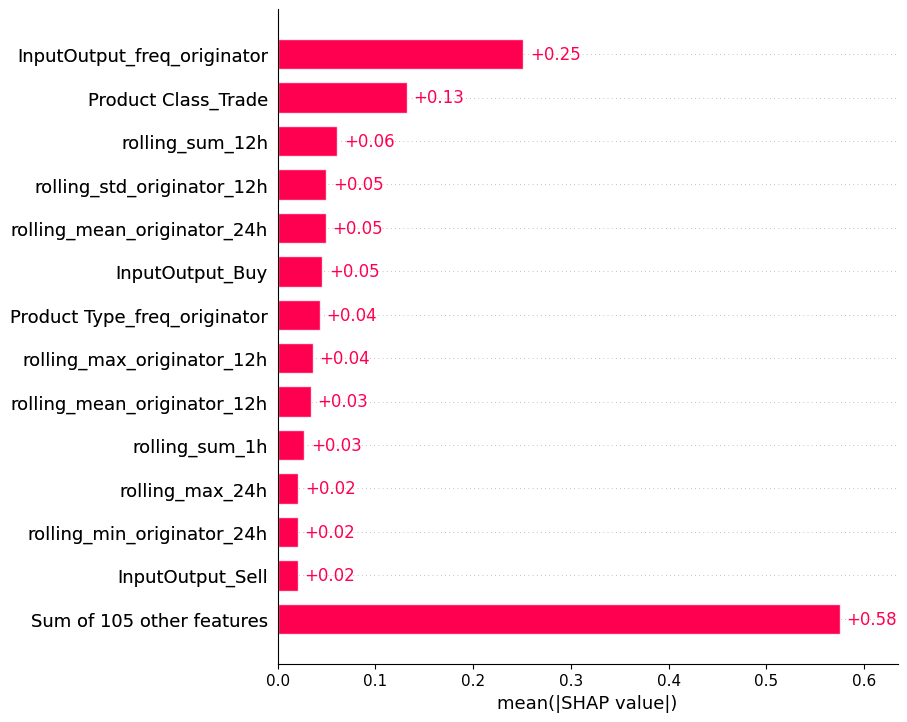

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [328]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_CM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
4


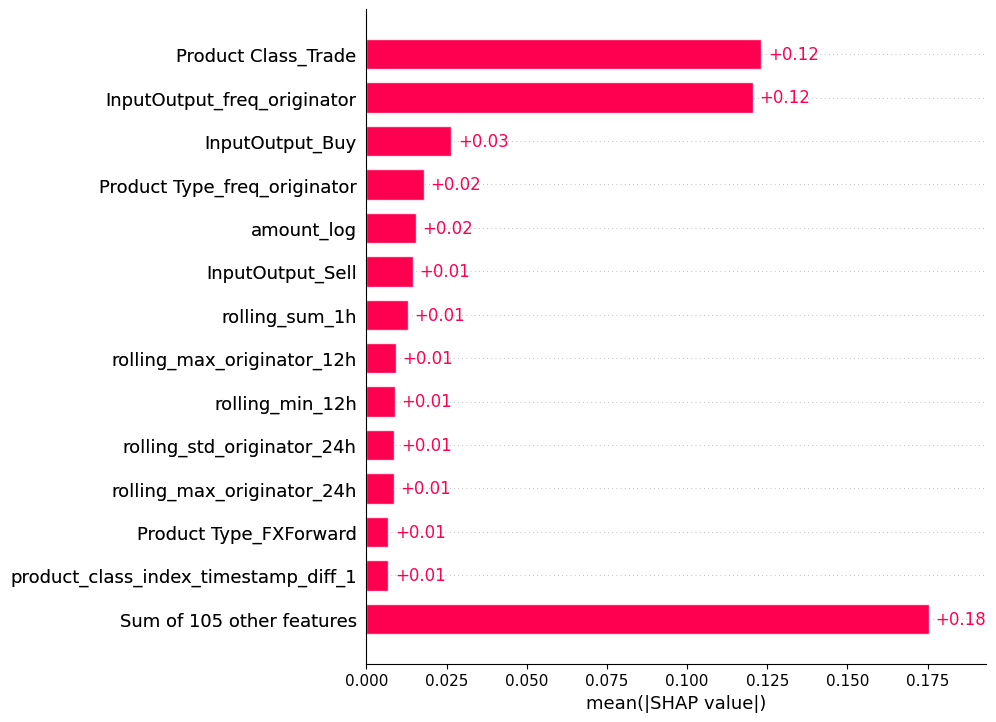

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [329]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')


## 2.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.  


In [339]:
idx = 51761 #2762376
#idx = 2762376

anomaly_type = 5
X_train_a = X_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(y_train_a.shape)

(47246, 118)
(47246,)


In [340]:
x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

(1, 118)
[[0.1428284 1.        0.        1.        0.        0.       ]]
5
5


In [341]:
df_correct_preds.filter(pl.col("index") == 2762376)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2762376,5,29315121,2019-03-25 20:57:30,"""Client_066""",5,1,0.313846,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,1,0,1,25,20,57,false,2.722976,1.960468,1.622718,1.445076,1.340454,-0.669069,-0.284955,-0.112912,0.0,0.0,1.04478,-0.917766,-0.698787,-0.576665,-0.484611,2.420729,-0.183119,-0.071133,0.0,0.0,0.742409,-0.000208,-1.474181,-2.09058,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,0.575268,1.291715,-0.404574,-0.763154,-0.902047,-0.807294,-0.01851,

In [342]:
df_correct_preds.filter(pl.col("index") == 51761)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
51761,5,27267021,2019-03-18 08:25:02,"""Client_269""",5,1,0.142828,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,18,8,25,false,2.706623,1.948048,1.612494,1.436176,1.33245,-0.669069,-0.284955,-0.112912,0.0,0.0,0.310631,0.766369,1.71438,1.997665,2.296045,2.411019,-0.183119,-0.071133,0.0,0.0,-0.953268,-0.000208,1.078086,-2.42795,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,-0.831225,-1.144312,0.627442,0.324539,0.360447,-0.903688,0.146866,-1.84126

In [343]:
# id = 51761
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.1, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

(42, 118)
(42,)
[ 97   1 115  86  77  94  36  51  53  78]
num of non-zero features: 18
rolling_min_originator_24h: -1.3914481105132488
InputOutput_Buy: -0.9919323370494959
Product Class_freq_originator: 0.9721944211546184
rolling_mean_originator_7d: -0.888375460817695
rolling_min_24h: -0.6300457648343952
rolling_max_originator_7d: -0.5837877373872176
market_index_timestamp_diff_1: 0.35616248948819523
originator_index_amount_diff_1: 0.3162996608412803
product_type_index_amount_diff_1: -0.3144041703378875
rolling_min_7d: -0.2582233958805658


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


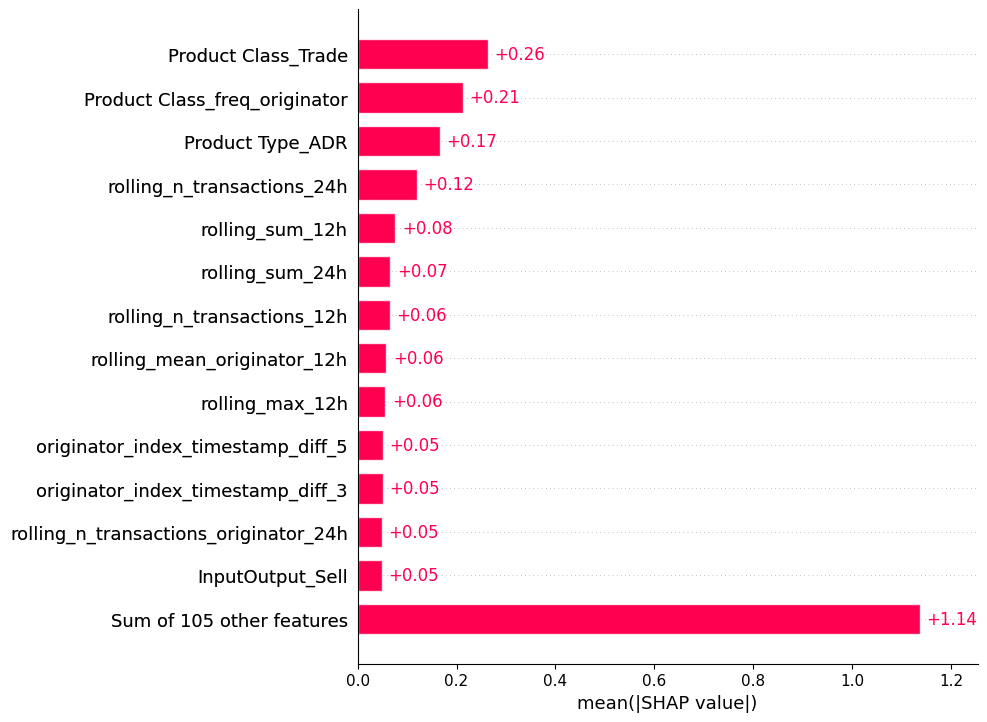

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [344]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_CM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


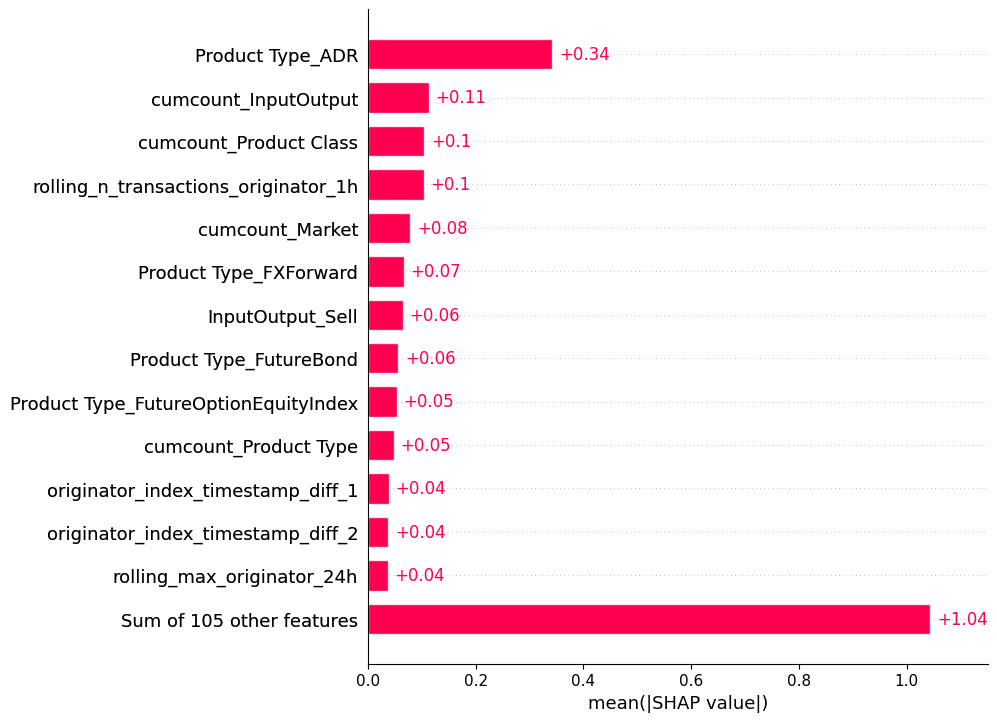

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [345]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')


In [337]:
# id = 2762376
lasso_x_train, lasso_y_train = find_knn(x, X_train_n, y_train_n, X_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

(42, 118)
(42,)
[ 25 115  46 114 116 117 111 110 109 108]
num of non-zero features: 3
Product Class_Cash in / out (withdrawal), Security in / out: 4.738852587523664
Product Class_freq_originator: 0.08474475738479219
product_class_index_timestamp_diff_1: 0.056445803244037036
Product Type_freq_originator: -0.0
Currency_freq_originator: 0.0
unusual_hour: 0.0
cumcount_Currency: -0.0
cumcount_Product Class: 0.0
cumcount_Product Type: -0.0
cumcount_Market: -0.0


Using 2998 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


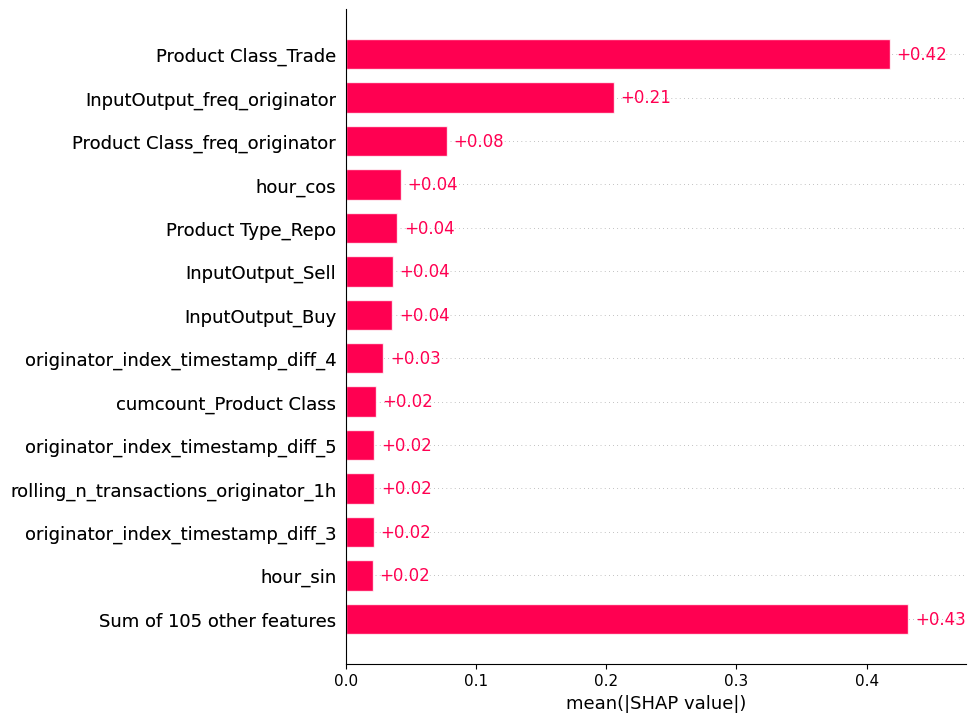

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [338]:
get_shap_explanations_mlp_class(model, X_train_shap, x, feature_names, filename='figs/shap_plots/shap_CM')


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


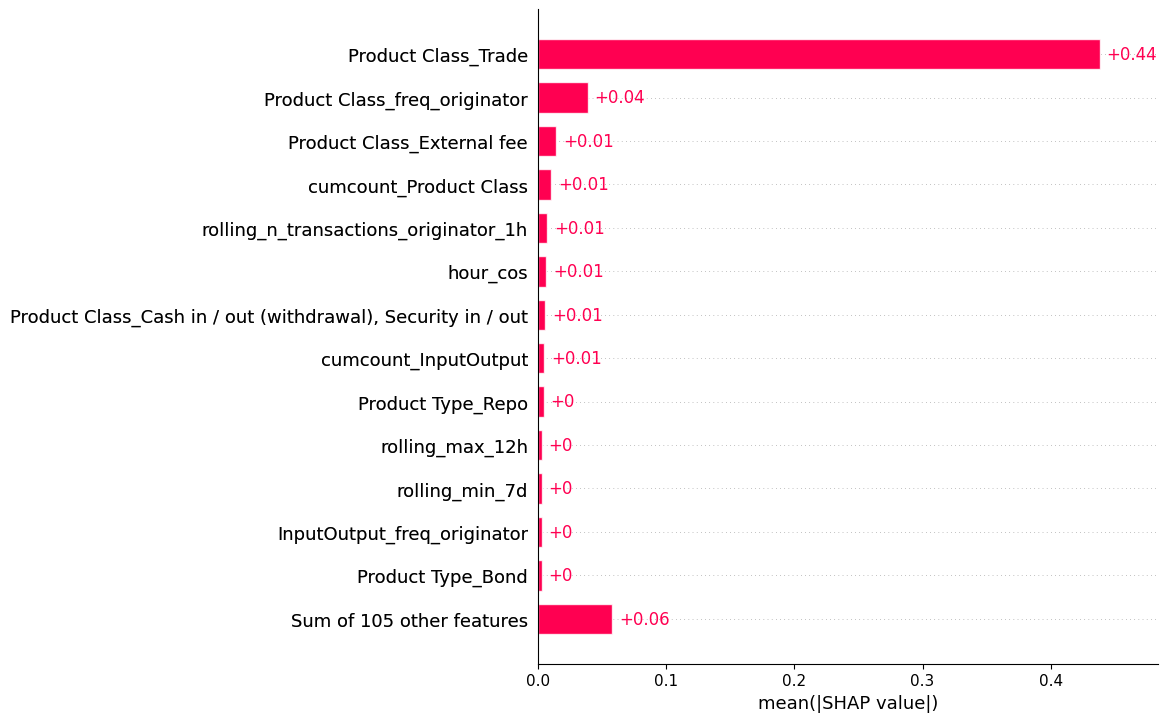

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [141]:
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_CM_lasso')


In [151]:
y_pred = lasso_classifier.predict(x)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[0.6994986]
R squared training set 0.7953135524789814


# 3. Explanations on latent space

In [159]:
z_train_n = z_train[y_pred_train == 0]
y_train_n = y_pred_train[y_pred_train == 0]
print(z_train_n.shape)
print(y_train_n.shape)

(24336122, 16)
(24336122,)


## 3.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  

In [178]:
anomaly_type = 1
#idx = 8357	
#idx = 47208
#idx = 59510
idx = 51542
k = 21

In [179]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(11970, 16)
(11970,)


In [180]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 118])
tensor([[-1.3714,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
1
1


(1, 16)

In [172]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
47208,1,27375818,2019-03-18 08:17:00,"""Client_269""",1,1,-1.416316,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,18,8,17,false,2.706586,1.94804,1.612479,1.436153,1.332431,-0.669069,-0.284955,-0.112912,0.0,0.0,1.03714,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-0.87333,-0.000208,-1.231524,0.000056,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,-1.406448,-0.148033,0.566826,0.318279,0.35306,-0.909154,0.138397,-1.

In [168]:
lasso_x_train, lasso_y_train = find_knn(test_transaction_latent, z_train_n, y_train_n, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

(42, 16)
(42,)
[11  1  8 15  4 13 10 14  9 12]
z_11: -0.29062095284461975
z_1: 0.24802157282829285
z_8: -0.17300806939601898
z_15: 0.0658140629529953
z_4: 0.024636447429656982
z_13: -0.010648652911186218
z_10: -0.006916834972798824
z_14: 0.0
z_9: -0.0
z_12: 0.0


In [182]:
#idx = 51542

lasso_x_train, lasso_y_train = find_knn(test_transaction_latent, z_train_n, y_train_n, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

(42, 16)
(42,)
[ 1  8 11  0  4 15 12 14  9 10]
z_1: 0.17854613065719604
z_8: -0.11120414733886719
z_11: -0.11007959395647049
z_0: -0.09409362077713013
z_4: 0.07437613606452942
z_15: 0.01279071532189846
z_12: -0.0
z_14: -0.0
z_9: -0.0
z_10: -0.0


In [173]:
#idx = 47208
lasso_x_train, lasso_y_train = find_knn(test_transaction_latent, z_train_n, y_train_n, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

(42, 16)
(42,)
[ 6 10  3  4  2 14  9 15  7 11]
z_6: 0.46722501516342163
z_10: -0.3853633999824524
z_3: -0.23435214161872864
z_4: 0.16111794114112854
z_2: -0.16026945412158966
z_14: 0.08133828639984131
z_9: -0.045592185109853745
z_15: 0.03949262201786041
z_7: -0.02752044051885605
z_11: -0.0


In [177]:
#idx = 59510
lasso_x_train, lasso_y_train = find_knn(test_transaction_latent, z_train_n, y_train_n, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=2000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

(42, 16)
(42,)
[ 4  6  3  1  2 12 14 15  8  9]
z_4: 0.4833335876464844
z_6: 0.31866058707237244
z_3: -0.25987526774406433
z_1: 0.19272270798683167
z_2: -0.1560300588607788
z_12: 0.04823513701558113
z_14: -0.02607831358909607
z_15: 0.0
z_8: 0.0
z_9: -0.0


In [197]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[3.9602852]
R squared training set 0.7354124784469604


## 3.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [253]:
anomaly_type = 2
idx = 2762998
#idx = 8891
#idx = 9186

In [254]:
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(3075, 16)
(3075,)


In [255]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[-0.1537,  0.0000,  1.0000,  0.0000,  0.0000,  1.0000]])
2
2


(1, 16)

In [256]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2762998,2,29358356,2019-03-25 20:58:44,"""Client_126""",2,1,-0.153726,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,25,20,58,true,1.976088,1.405621,1.183206,1.062452,0.996917,1.666501,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-0.92282,-1.812988,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,0.437069,1.344762,-0.20075,-0.763227,-0.89009,-0.796219,-0.016536,1.158688,0.548016

In [257]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[ 7024447 16785908 15389272 17173201 18709443  1985380 13342260 10973830
  22879734]]
[[2.38548064 2.74158287 2.77904725 2.78241467 2.7916584  2.81790018
  2.83059764 2.8639226  2.88578558]]
[[2003 1680 2585 2584 2852 2334 2028 2609 2331]]
[[1.31661534 1.47595024 1.56430936 1.58656859 1.62715888 1.63853288
  1.68013847 1.69776201 1.70690382]]


In [258]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [214]:
# idx = 8891
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.         -0.         -0.         -0.11740979  0.
  0.         -0.         -0.          0.14261469  0.         -0.
 -0.          0.         -0.59548354 -0.        ]


In [251]:
#idx = 9186
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.         -0.         -0.         -0.04059238  0.
  0.         -0.         -0.          0.07508865  0.         -0.
 -0.          0.06717732 -0.67675436 -0.        ]


In [259]:
#idx = 2762998
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.          0.          0.          0.4288372  -0.21016456 -0.
  0.         -0.         -0.          0.          0.07228045 -0.
 -0.          0.         -0.7131233   0.        ]


In [218]:
# idx = 8891
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  9  4 13 12 11 10 15  8  7]
z_14: -0.5954835414886475
z_9: 0.1426146924495697
z_4: -0.11740978807210922
z_13: 0.0
z_12: -0.0
z_11: -0.0
z_10: 0.0
z_15: -0.0
z_8: -0.0
z_7: -0.0


In [252]:
#idx = 9186
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  9 13  4 12 11 10 15  8  7]
z_14: -0.676754355430603
z_9: 0.07508864998817444
z_13: 0.06717731803655624
z_4: -0.04059237986803055
z_12: -0.0
z_11: -0.0
z_10: 0.0
z_15: -0.0
z_8: -0.0
z_7: -0.0


In [261]:
#idx = 2762998
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  3  4 10 12 11 13 15  8  9]
z_14: -0.7131233215332031
z_3: 0.42883720993995667
z_4: -0.21016456186771393
z_10: 0.07228045165538788
z_12: -0.0
z_11: -0.0
z_13: 0.0
z_15: 0.0
z_8: -0.0
z_9: 0.0


In [217]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[1.8182106]
R squared training set 0.9356386065483093


## 3.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [295]:
anomaly_type = 3
#idx = 1260		
#idx = 1157
idx = 2191296
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(11425, 16)
(11425,)


In [296]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.4377, 0.0000, 1.0000, 1.0000, 0.0000, 0.0000]])
3
3


(1, 16)

In [297]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2191296,3,29582320,2019-03-25 04:55:24,"""Client_066""",3,1,0.437687,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,1,25,4,55,false,2.720786,1.958762,1.621336,1.443876,1.339378,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,1.014191,-0.000208,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,-1.016961,2.991005,0.831314,1.143892,4.9937,7.037661,8.281472,-0.384886,-6.23429,-5.238993,-7.187119,

In [298]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[19181254  4550302 19181207  4550311  4550573 19181273  4551119  4549768
  19181228]]
[[2.00121045 2.05460787 2.06765532 2.07407093 2.07464314 2.09097219
  2.09130216 2.11779213 2.12236404]]
[[ 5888  4770  5929  5902  5856  5883  5868 10495  4838]]
[[1.13939023 1.14369786 1.3032707  1.35032642 1.36107588 1.36896372
  1.40083265 1.40411448 1.41559124]]


In [299]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [300]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[ 0.         -0.          0.         -0.         -0.          0.
 -0.00651955 -0.          0.          0.          2.3100157   0.
 -0.          0.         -0.6542186   0.        ]


In [270]:
# idx = 1260
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[15  9 14 13 12 11 10  8  7  6]
z_15: 1.6302036046981812
z_9: 1.4055988788604736
z_14: -0.5636571645736694
z_13: 0.0
z_12: 0.0
z_11: 0.0
z_10: 0.0
z_8: -0.0
z_7: -0.0
z_6: -0.0


In [278]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[15  4  3  8 12 11 13 14  9 10]
z_15: 1.805695652961731
z_4: -1.358310580253601
z_3: 1.0342575311660767
z_8: 0.10734690725803375
z_12: -0.0
z_11: 0.0
z_13: 0.0
z_14: -0.0
z_9: 0.0
z_10: 0.0


In [301]:
#idx= 2191296
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[10 14  6 13 12 11  9 15  8  7]
z_10: 2.3100156784057617
z_14: -0.6542186141014099
z_6: -0.006519550457596779
z_13: 0.0
z_12: -0.0
z_11: 0.0
z_9: 0.0
z_15: 0.0
z_8: 0.0
z_7: -0.0


## 2.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  


In [333]:
anomaly_type = 4
#idx = 16483
#idx = 43121
idx = 1578200
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(60973, 16)
(60973,)


In [334]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.2837, 0.0000, 1.0000, 0.0000, 1.0000, 0.0000]])
4
4


(1, 16)

In [335]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1578200,4,28389041,2019-03-21 13:52:58,"""Client_126""",4,1,0.283702,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,4,21,13,52,false,1.868977,1.324096,1.099986,0.991582,0.93298,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,0.456582,-0.000208,-0.000167,0.000056,-0.1313,-1.087529,1.212389,-0.80366,-0.068142,-1.16148,1.144188,0.831028,-0.071814,-0.968032,-0.420084,-0.36045,0.033574,0.121585,0.3093

In [336]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[22637796  6515247 14918450 21045242 23973410 18005843 18596616 17494687
  24128359]]
[[2.09333301 2.20503902 2.21301699 2.23646998 2.27940512 2.28431606
  2.3295927  2.33245277 2.35924649]]
[[51779 51782 51854 51914 51770 51685 51789 51686 56578]]
[[0.6487757  0.66346639 0.7476024  0.81965625 0.82133055 0.83718187
  0.86397141 0.86418015 0.87199795]]


In [337]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [338]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[-0.         -0.         -0.          0.68520284 -1.7985528   0.
 -0.         -0.         -0.          0.          0.         -0.51679516
  0.         -0.9433232  -0.         -0.39799213]


In [313]:
# idx = 16483
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[14  2 11 15 12 10  9 13  8  7]
z_14: -0.8668021559715271
z_2: -0.6827273368835449
z_11: -0.5504565238952637
z_15: -0.12361042946577072
z_12: 0.0
z_10: 0.0
z_9: 0.0
z_13: -0.0
z_8: 0.0
z_7: -0.0


In [330]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[11 15 13  3 14  0 12 10  8  9]
z_11: -1.0144938230514526
z_15: -0.3820912539958954
z_13: -0.20467519760131836
z_3: 0.18361549079418182
z_14: -0.13533329963684082
z_0: -0.08610198646783829
z_12: 0.0
z_10: 0.0
z_8: 0.0
z_9: -0.0


In [339]:
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 4 13  3 11 15 10 12 14  8  9]
z_4: -1.7985527515411377
z_13: -0.9433231949806213
z_3: 0.6852028369903564
z_11: -0.5167951583862305
z_15: -0.3979921340942383
z_10: 0.0
z_12: 0.0
z_14: -0.0
z_8: -0.0
z_9: 0.0


In [340]:
y_pred = lasso_classifier.predict(test_transaction_latent)
print(y_pred)
print('R squared training set', lasso_classifier.score(lasso_x_train, lasso_y_train))

[3.3733356]
R squared training set 0.9586156010627747


## 3.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.   

In [361]:
# idx = 37661
# idx = 2762376
idx = 2742220
anomaly_type = 5
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(z_train_a.shape)
print(y_train_a.shape)

(68173, 16)
(68173,)


In [362]:
x = torch.tensor(X_test[idx], dtype=torch.float32).reshape(1, -1)
#x = X_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

model.encoder.eval()
test_transaction_latent = model.encoder(x)
test_transaction_latent = test_transaction_latent.cpu().detach().numpy()
test_transaction_latent = test_transaction_latent.reshape(1, -1)
test_transaction_latent.shape

torch.Size([1, 121])
tensor([[0.1276, 1.0000, 0.0000, 1.0000, 0.0000, 0.0000]])
5
5


(1, 16)

In [363]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2742220,5,29315163,2019-03-25 20:19:22,"""Client_066""",5,1,0.127558,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,25,20,19,false,2.722951,1.96039,1.622662,1.44503,1.340415,-0.669069,-0.284955,-0.112912,0.0,0.0,1.041646,1.371174,-0.698787,-0.576665,-0.484611,2.420702,-0.183119,-0.071133,0.0,0.0,-0.984276,-0.000208,-1.487097,-2.44517,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,-1.344977,-0.437218,-1.523585,-0.726696,-0.866729,-0.731116,0.209802,1.177584,0.490627

In [364]:
knn_normal = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_normal.fit(z_train_n)
distances_n, indices_n = knn_normal.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_n)
print(distances_n)

knn_anomaly = NearestNeighbors(n_neighbors=k, algorithm='auto', metric='euclidean')
knn_anomaly.fit(z_train_a)
distances_a, indices_a = knn_anomaly.kneighbors(test_transaction_latent, n_neighbors=k)
print(indices_a)
print(distances_a)

[[2224812 2445974 2486129 2863133 2452079 3157412 2840016 1799853  537756]]
[[3.30597401 3.36121106 3.45149326 3.50405145 3.50886726 3.53707814
  3.54500651 3.54833174 3.55391145]]
[[36947 64918 64916 64913 32603 29873 19184 32601 64888]]
[[0.73515326 0.8501938  0.88848692 0.93049419 0.94628245 0.96698058
  0.97500175 0.97839004 1.01206148]]


In [365]:
lasso_x_train = np.vstack((z_train_n[indices_n.flatten().tolist()], z_train_a[indices_a.flatten().tolist()]))
lasso_y_train = np.concatenate((y_train_n[indices_n.flatten().tolist()], y_train_a[indices_a.flatten().tolist()]))

print(lasso_x_train.shape)
print(lasso_y_train.shape)

(18, 16)
(18,)


In [366]:
lasso_classifier = Lasso(alpha=0.1)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

[ 0.          0.81061304 -0.          0.         -0.          0.
 -0.1136227  -0.         -0.9288145   0.          0.         -0.83087265
  1.3570399  -0.         -0.38097972 -0.        ]


In [348]:
# idx = 16483
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 4  7 13  8 10  0 11  1 15  9]
z_4: -2.842630624771118
z_7: -1.797913908958435
z_13: -1.7776914834976196
z_8: -0.8401194214820862
z_10: 0.7909547090530396
z_0: -0.6901487708091736
z_11: -0.5478876233100891
z_1: 0.5196952819824219
z_15: -0.3222387135028839
z_9: -0.0


In [356]:
#idx = 2762376
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[ 6  4  8  1 12 14 13 15  9 10]
z_6: -1.2893599271774292
z_4: -1.1086502075195312
z_8: -1.0477161407470703
z_1: 0.3213449716567993
z_12: 0.31699803471565247
z_14: -0.08331853151321411
z_13: -0.0
z_15: -0.0
z_9: 0.0
z_10: 0.0


In [367]:
#idx = 2742220
sorted_importance = show_importance_latent(lasso_classifier.coef_, n_features=10)

[12  8 11  1 14  6 13 15  9 10]
z_12: 1.3570399284362793
z_8: -0.9288144707679749
z_11: -0.830872654914856
z_1: 0.8106130361557007
z_14: -0.3809797167778015
z_6: -0.11362269520759583
z_13: -0.0
z_15: -0.0
z_9: 0.0
z_10: 0.0


# 4. Knn on latent space, Explanations on input space

In [34]:
X_train_n = X_train[y_pred_train == 0]
y_train_n = y_pred_train[y_pred_train == 0]
z_train_n = z_train[y_pred_train == 0]
print(X_train_n.shape)
print(z_train_n.shape)
print(y_train_n.shape)

(24336122, 118)
(24336122, 16)
(24336122,)


## 4.1. Small but highly frequent transactions generated within a short timeframe:
A pattern that contains multiple transactions below applicable reporting thresholds.  

In [ ]:
df_train_n = df_train.filter(pl.col('Model Prediction') == 0)

In [20]:
df_correct_preds.filter(pl.col("Anomaly") == 1)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,…,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
8357,1,27181276,2019-03-18 07:07:36,"""Client_126""",1,1,-1.374993,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,…,-6.150071,0.221189,-2.867951,-5.487623,-6.993079,-0.611904,-2.789759,-8.319886,-10.27966,-0.527784,-3.272966,-9.434822,-11.810767,-0.993851,0.231534,1.407106,1.719164,0.927201,-3.093492,-3.848477,-4.589277,-0.970284,-2.270328,-2.661877,-3.286839,-0.930763,-0.26029,0.127359,0.383433,-0.206731,0.000268,-2.807199,0.872758,1.498969,-0.519094,0.627225,false
38329,1,26944892,2019-03-18 08:01:16,"""Client_389""",1,1,-1.448741,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,…,-3.728602,0.220285,-0.822469,-3.226645,-4.142744,-0.868864,-0.573562,-2.960667,-3.724281,-0.285426,-0.622197,-3.095749,-4.04661,0.236758,0.242394,0.57021,0.844807,0.107114,-0.986406,-2.545283,-3.203274,-0.855631,-0.849216,-1.893241,-2.486757,-0.792986,-0.132105,-0.132266,0.246361,-0.581375,-0.543008,-0.513675,-0.322452,0.6808,-1.375441,-1.602753,false
47208,1,27375818,2019-03-18 08:17:00,"""Client_269""",1,1,-1.416316,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,1,…,-3.397887,0.219996,0.674829,1.555806,1.886322,0.233441,0.702829,1.221233,1.391004,0.163924,0.630139,0.349025,0.172582,-0.13632,0.004147,0.820108,1.105891,0.668905,0.058605,-1.012198,-1.57277,-0.531864,-0.460665,-1.538121,-2.117108,-0.558488,0.080863,0.038831,0.381779,-0.459265,-0.365824,0.5429,-0.315793,0.581652,-1.424823,-1.597544,false
51542,1,27058562,2019-03-18 08:24:40,"""Client_066""",1,1,-1.371359,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,…,-3.257968,0.219992,-0.134602,-0.519891,-0.730435,-0.921131,0.14653,-0.071032,-0.18969,-0.018942,0.226287,-0.067813,-0.337965,0.846607,0.007705,0.829295,1.115489,0.832207,-0.293578,-1.17673,-1.747757,-0.613736,-0.352478,-1.149263,-1.712341,-0.543705,-0.083504,-0.566928,0.781142,0.30661,0.293335,-6.547604,-1.708287,2.175883,0.252893,0.617072,false
59510,1,27375815,2019-03-18 08:38:54,"""Client_269""",1,1,-1.40766,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1

In [95]:
anomaly_type = 1
idx = 8357	
#idx = 47208
#idx = 59510
#idx = 51542

In [82]:
X_train_a = X_train[y_pred_train == anomaly_type]
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(z_train_a.shape)
print(y_train_a.shape)

(11970, 118)
(11970, 16)
(11970,)


In [96]:
x = z_test[idx].reshape(1, -1)

print(x.shape)
print(y_test[idx])
print(y_pred_test[idx])
print(X_test[idx][:6])



(1, 16)
1
1
[-1.37499299  1.          0.          1.          0.          0.        ]


In [84]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
8357,1,27181276,2019-03-18 07:07:36,"""Client_126""",1,1,-1.374993,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,7,7,true,2.040487,1.445817,1.199385,1.077004,1.010305,-0.669069,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,2.410951,-0.183119,-0.071133,0.0,0.0,-1.058838,-0.000208,-0.000167,-2.606994,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.831225,1.143892,-1.830154,-3.55436,-4.216388,-0.910444,-3.52996

In [102]:
lasso_x_train, lasso_y_train, _ = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [103]:
lasso_classifier = Lasso(alpha=0.01, max_iter=10000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01, max_iter=10000)

In [104]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 32  73  78  31  91 114  74   0  97  83]
num of non-zero features: 28
originator_index_timestamp_diff_2: 0.2048820985468297
rolling_max_24h: -0.14341316505753196
rolling_min_7d: 0.13572357571030416
originator_index_timestamp_diff_1: 0.12572016747274986
rolling_max_originator_1h: -0.08234761133284732
Product Type_freq_originator: 0.08092011511525618
rolling_max_7d: 0.07537364631473709
amount_log: 0.06713820741454178
rolling_min_originator_24h: -0.046430011886396866
rolling_mean_originator_1h: -0.043008106489620924


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
1


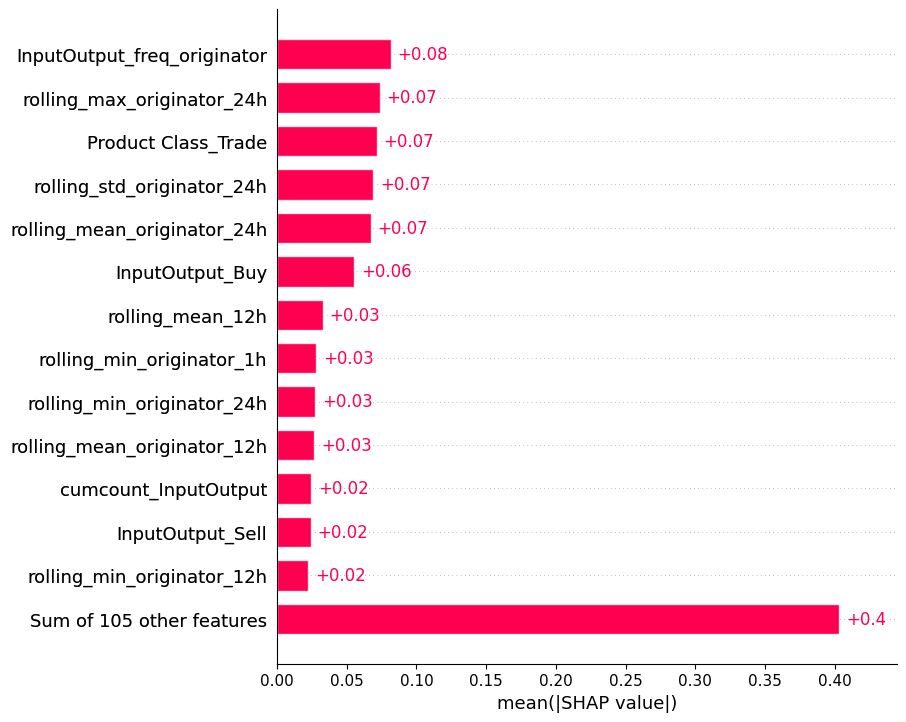

Saved SHAP plots for class 1 to output/shap_plots/
SHAP explanations generated and saved.


In [90]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent')

In [105]:
# This method chooses normal transactions randomly
lasso_x_train, lasso_y_train, indices_r = select_random_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [106]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[103  79  84 112  62 115  51  57  94  85]
num of non-zero features: 23
rolling_n_transactions_originator_1h: -0.06117618027696656
rolling_n_transactions_1h: -0.05046434437172158
rolling_mean_originator_12h: -0.046084459976102686
InputOutput_freq_originator: -0.04423939199014726
rolling_mean_7d: -0.038834506558701284
Product Class_freq_originator: -0.038608297048965824
originator_index_amount_diff_1: -0.034782158348877115
hour_sin: -0.0261907602159451
rolling_max_originator_7d: 0.017764089279792786
rolling_mean_originator_24h: -0.015363900465457011


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
1


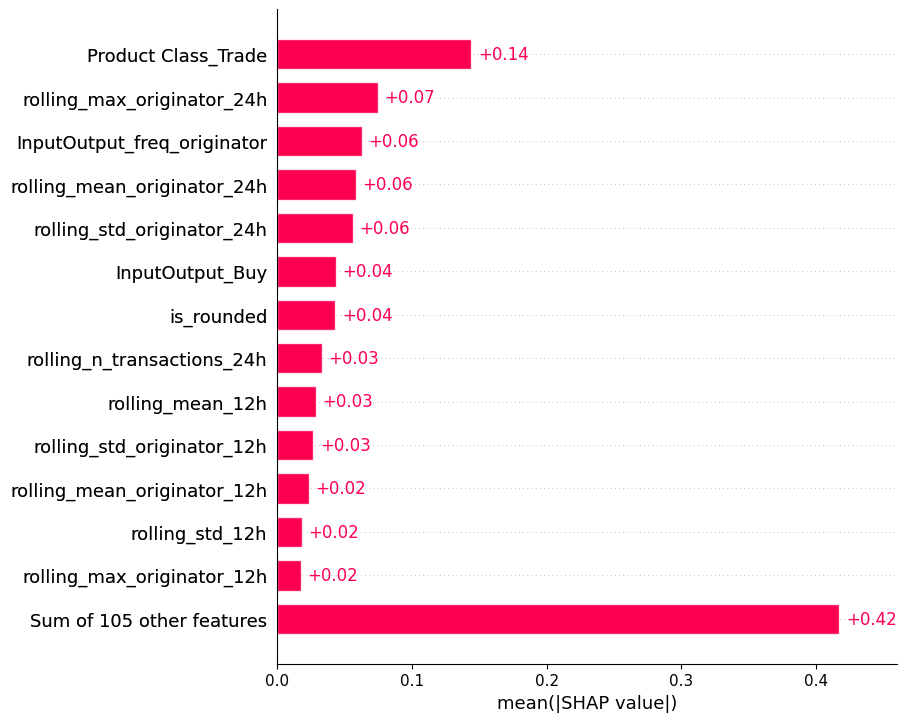

Saved SHAP plots for class 1 to output/shap_plots/
SHAP explanations generated and saved.


In [107]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent_random')

## 4.2. Transactions with rounded normalized amounts bought or sold within an account:
It is unusual for transactions in capital markets to have rounded amounts (unless they occur in markets where foreign exchange conversion causes rounding errors).  


In [108]:
anomaly_type = 2
idx = 2762998
#idx = 8891

In [57]:
#df_correct_preds.filter(pl.col("Anomaly") == 2)

In [109]:
X_train_a = X_train[y_pred_train == anomaly_type]
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(z_train_a.shape)
print(y_train_a.shape)

(2657, 118)
(2657, 16)
(2657,)


In [117]:
x = z_test[idx].reshape(1, -1)

print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])

x

(1, 16)
[[ 1.9777862   1.3265679  -0.18509047 -2.7718105   1.9612039   0.05263892]]
2
2


array([[ 1.9777862 ,  1.3265679 , -0.18509047, -2.7718105 ,  1.9612039 ,
         0.05263892,  0.44548422,  3.820513  , -1.6609604 , -1.5207852 ,
        -2.513419  , -1.2880766 ,  3.8947668 , -4.1783147 , -0.7682023 ,
         1.0985036 ]], dtype=float32)

In [21]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
2762998,2,29358356,2019-03-25 20:58:44,"""Client_126""",2,1,-0.153726,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,25,20,58,true,1.976088,1.405621,1.183206,1.062452,0.996917,1.666501,-0.284955,-0.112912,0.0,0.0,-1.390533,-0.917766,-0.698787,-0.576665,-0.484611,-0.433523,-0.183119,-0.071133,0.0,0.0,-0.92282,-1.812988,-0.000167,0.000056,0.71708,1.365456,1.493561,0.276227,1.227968,1.900558,0.437069,1.344762,-0.20075,-0.763227,-0.89009,-0.796219,-0.016536

In [111]:
lasso_x_train, lasso_y_train, indices = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [112]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[112  36  84  51  52  94 113  80  83  86]
num of non-zero features: 22
InputOutput_freq_originator: 0.42265572499601267
market_index_timestamp_diff_1: -0.12570872661204321
rolling_mean_originator_12h: -0.11199737100847752
originator_index_amount_diff_1: -0.10488150210267348
market_index_amount_diff_1: -0.08985696151653169
rolling_max_originator_7d: -0.08011685149962587
Market_freq_originator: -0.06911205791627419
rolling_n_transactions_12h: 0.06056776678411425
rolling_mean_originator_1h: -0.053782811144381354
rolling_mean_originator_7d: 0.05237111782147215


In [115]:
# important features like is_rounded  equal to 0 in most normal transactions that are closest to the selected anomaly
df_train_n[indices.flatten().tolist()].select(pl.col(['index','Anomaly', 'is_rounded']))

index,Anomaly,is_rounded
u32,i64,bool
21316261,0,true
10978643,0,true
18899087,0,true
7642662,0,true
20413030,0,true
…,…,…
4570322,0,true
23975638,0,true
12332338,0,true


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
2


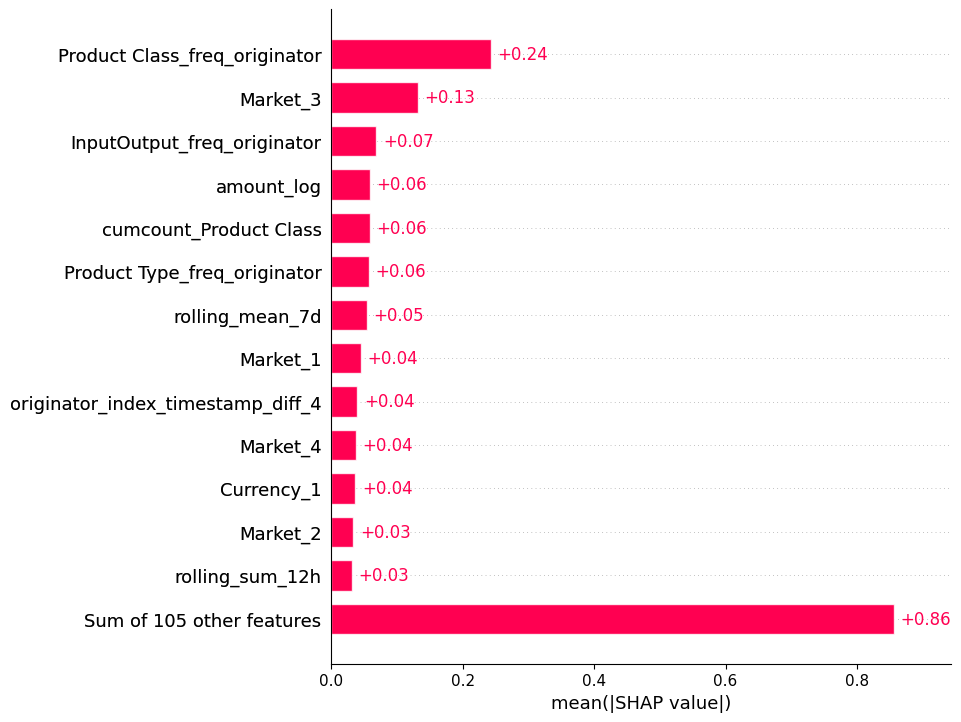

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [116]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent')

In [118]:
# This method chooses normal transactions randomly
lasso_x_train, lasso_y_train, indices_r = select_random_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [119]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 30 112   1  91 103 113  47 114  72 115]
num of non-zero features: 9
is_rounded: 1.685792246835178
InputOutput_freq_originator: 0.0582283441528563
InputOutput_Buy: -0.03535918802536331
rolling_max_originator_1h: -0.022076455922625342
rolling_n_transactions_originator_1h: -0.01768597273041215
Market_freq_originator: -0.006228637307199842
product_class_index_timestamp_diff_2: -0.004235031486797625
Product Type_freq_originator: 0.002989967878590655
rolling_max_12h: 0.0010509419831152746
Product Class_freq_originator: -0.0


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
2


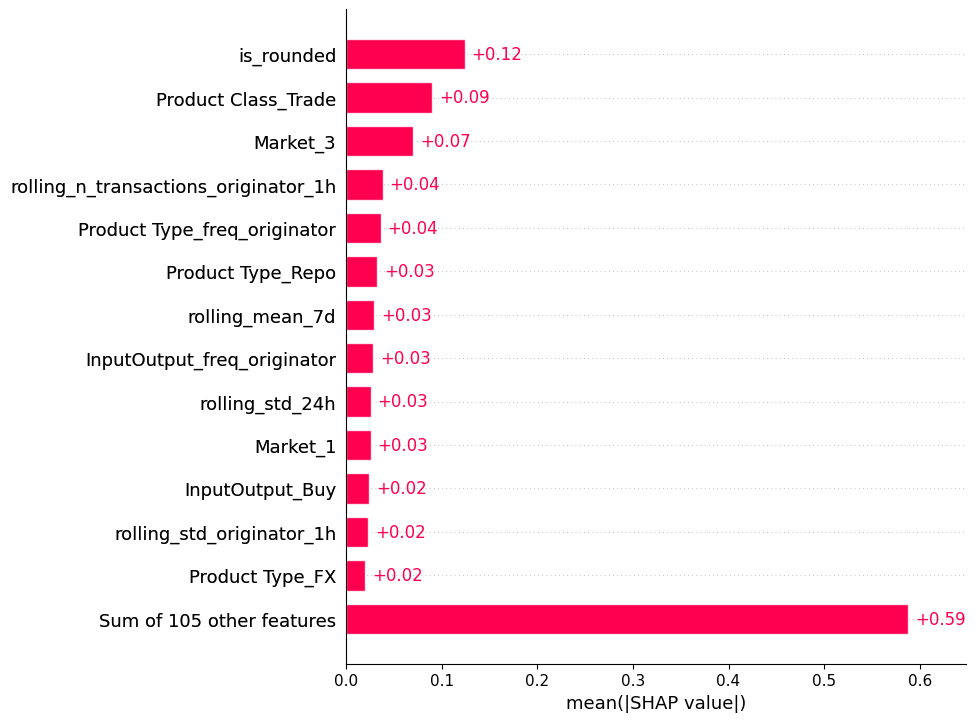

Saved SHAP plots for class 2 to output/shap_plots/
SHAP explanations generated and saved.


In [120]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent_random')

## 4.3. Security bought or sold at an unusual time:
It is unusual for clients to trade specific securities outside of a specific timeframe (for example, outside of the opening and closing times of a stock exchange).  


In [122]:
anomaly_type = 3
idx = 1165
#idx = 2191351

In [123]:
X_train_a = X_train[y_pred_train == anomaly_type]
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(z_train_a.shape)
print(y_train_a.shape)

(17102, 118)
(17102, 16)
(17102,)


In [142]:
x = z_test[idx].reshape(1, -1)
print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])
x


(1, 16)
[[ 1.3216758   0.67581826  1.0972202  -1.7586157  -2.3357074  -0.41588423]]
3
3


array([[ 1.3216758 ,  0.67581826,  1.0972202 , -1.7586157 , -2.3357074 ,
        -0.41588423, -3.1873865 , -0.4752506 , -0.5826307 , -4.9376435 ,
        -2.3236742 , -2.9050512 ,  0.20851162,  0.730509  , -0.48823348,
         0.17480761]], dtype=float32)

In [125]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
1165,3,27021018,2019-03-18 02:03:40,"""Client_212""",3,1,0.517303,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,1,18,2,3,false,2.277038,1.623655,1.345376,1.204335,1.123912,-0.669069,-0.284955,-0.112912,0.0,0.0,1.036349,-0.917766,-0.698787,-0.576665,-0.484611,2.410612,-0.183119,-0.071133,0.0,0.0,-1.297503,-0.000208,1.22626,2.510179,0.71708,1.365456,0.513469,-1.287407,-0.415434,3.620574,-0.293992,1.383074,-8.062019,-2.551143,-3.032662,-0.88602,-7.795076,-7

In [127]:
lasso_x_train, lasso_y_train, indices = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [128]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 13  74 112  94  95 114  77  71  86  41]
num of non-zero features: 22
Product Type_FX: -1.5859552421141918
rolling_max_7d: -0.5848665346433474
InputOutput_freq_originator: 0.5817764339151377
rolling_max_originator_7d: -0.2665907215105786
rolling_min_originator_1h: 0.23282602568211205
Product Type_freq_originator: 0.19061242697218875
rolling_min_24h: 0.13303827551559605
rolling_max_1h: 0.09101566035561626
rolling_mean_originator_7d: -0.08526324738333316
product_type_index_timestamp_diff_1: 0.0782183085859406


In [140]:
# important features like is_rounded  equal to 0 in most normal transactions that are closest to the selected anomaly
df_train_n[indices.flatten().tolist()].select(pl.col(['index','Anomaly', 'unusual_hour']))

index,Anomaly,unusual_hour
u32,i64,bool
7116170,3,true
7116294,3,true
16913259,3,true
7116188,3,true
9588079,0,true
…,…,…
7116319,0,true
7116456,3,true
7116271,3,true


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
3


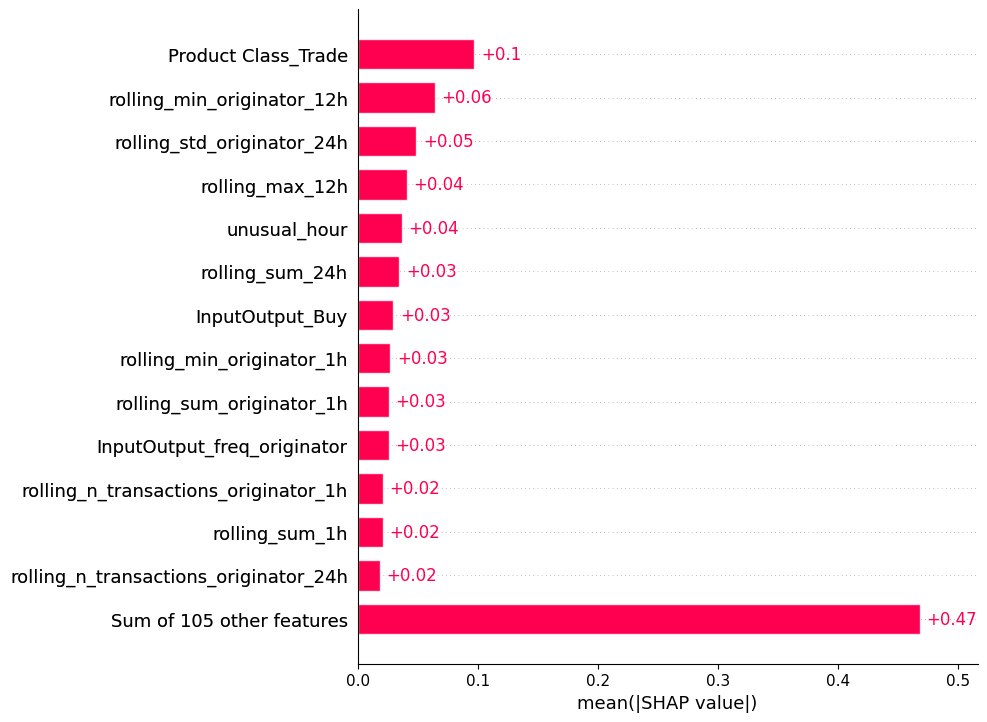

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [133]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_GM')

In [155]:
# This method chooses normal transactions randomly
lasso_x_train, lasso_y_train, indices_r = select_random_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01, max_iter=10000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01, max_iter=10000)

In [156]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 93  95  86 103  81 104  96  78  73 115]
num of non-zero features: 13
rolling_max_originator_24h: -0.1260488018233329
rolling_min_originator_1h: 0.09998932499480023
rolling_mean_originator_7d: 0.02659978517175939
rolling_n_transactions_originator_1h: 0.023255507444680065
rolling_n_transactions_24h: -0.023198917471516985
rolling_n_transactions_originator_12h: 0.013126965059716885
rolling_min_originator_12h: 0.012659138061785424
rolling_min_7d: 0.011811703329091885
rolling_max_24h: -0.010185183648771225
Product Class_freq_originator: 0.0014270684374089741


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
3


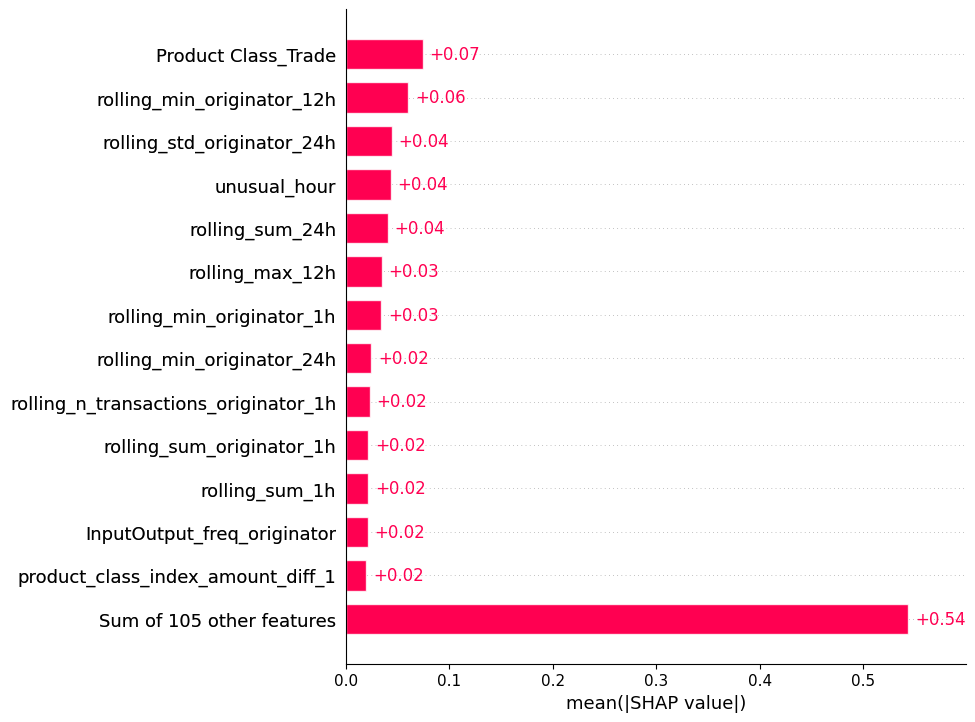

Saved SHAP plots for class 3 to output/shap_plots/
SHAP explanations generated and saved.


In [138]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent_random')

## 4.4. Large asset withdrawal:
A sudden spike in transaction amount withdrawn from an account or transferred out, which deviates from the previous transactional activity and is absent of any commercial rationale or related corporate action event.  

In [157]:
anomaly_type = 4
idx = 6072


In [158]:
X_train_a = X_train[y_pred_train == anomaly_type]
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(z_train_a.shape)
print(y_train_a.shape)

(36837, 118)
(36837, 16)
(36837,)


In [167]:
x = z_test[idx].reshape(1, -1)
print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])
x

(1, 16)
[[ 0.70570326  1.3338736   0.79975325 -2.145804   -1.3938534   1.0622181 ]]
4
4


array([[ 0.70570326,  1.3338736 ,  0.79975325, -2.145804  , -1.3938534 ,
         1.0622181 , -2.861633  , -1.4028045 ,  1.1473902 , -2.9717019 ,
        -1.0635842 , -0.02553808,  0.03482674, -0.2532283 , -3.58116   ,
        -1.1921524 ]], dtype=float32)

In [160]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
6072,4,27012257,2019-03-18 07:03:27,"""Client_066""",4,1,-0.075414,0,1,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,1,18,7,3,false,2.69419,1.938691,1.604789,1.429463,1.326415,-0.669069,-0.284955,-0.112912,0.0,0.0,1.09772,1.40166,1.740536,-0.576665,-0.484611,2.410947,-0.183119,-0.071133,0.0,0.0,0.923817,-0.000208,-1.179657,-2.945561,0.71708,1.365456,0.513469,-1.287407,-1.409974,1.270989,-0.293992,1.383074,-1.728126,-3.135742,-3.722448,-0.886677,-4.661549,-4.

In [162]:
lasso_x_train, lasso_y_train, _ = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [164]:
lasso_classifier = Lasso(alpha=0.01, max_iter=10000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01, max_iter=10000)

In [165]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[23 25 78  1 15 79 94 90 12 41]
num of non-zero features: 35
Product Type_SimpleTransfer: 3.1406002132130215
Product Class_Cash in / out (withdrawal), Security in / out: 2.913440633775111
rolling_min_7d: -1.4363859803123973
InputOutput_Buy: -0.9245435068591118
Product Type_FXSwap: -0.7851845078475934
rolling_n_transactions_1h: 0.7835231469867616
rolling_max_originator_7d: -0.5250714551307035
rolling_std_originator_7d: 0.4855389732403307
Product Type_Equity: 0.468322264246169
product_type_index_timestamp_diff_1: 0.33924894570294706


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
4


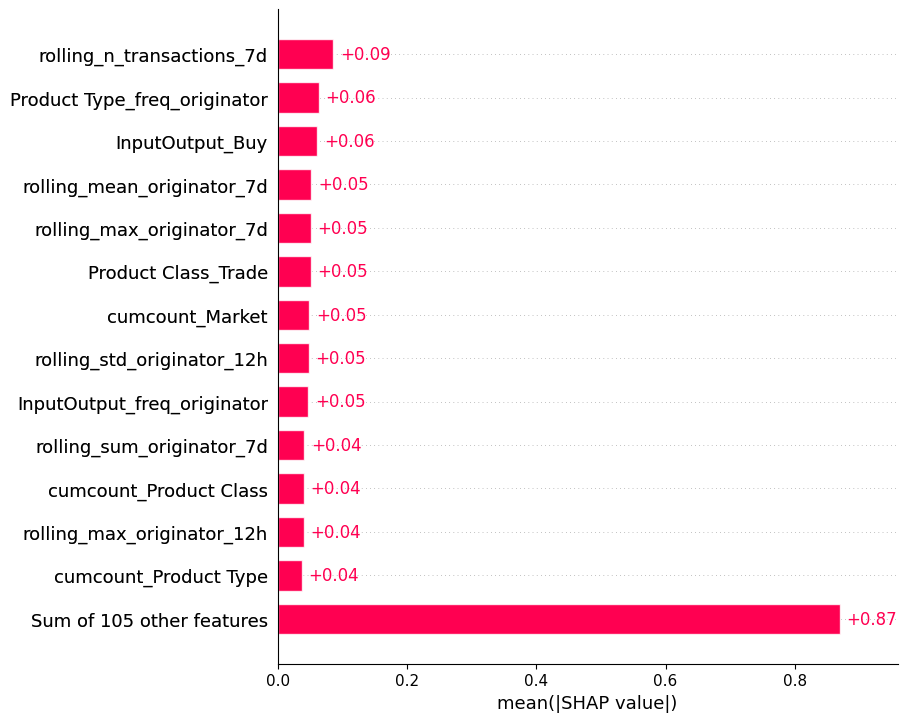

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [166]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent')

In [168]:
# This method chooses normal transactions randomly
lasso_x_train, lasso_y_train, indices_r = select_random_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [169]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 65  31  66 104  85  77  59  61  82 114]
num of non-zero features: 23
rolling_sum_24h: -0.4447663328508398
originator_index_timestamp_diff_1: 0.11756264548253847
rolling_sum_7d: -0.08197985038691609
rolling_n_transactions_originator_12h: 0.08003551939793833
rolling_mean_originator_24h: -0.07471862849849499
rolling_min_24h: 0.07042507317373253
rolling_mean_1h: 0.06184334384313243
rolling_mean_24h: -0.04504590611332523
rolling_n_transactions_7d: -0.033547631696018425
Product Type_freq_originator: -0.031258981321355


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
4


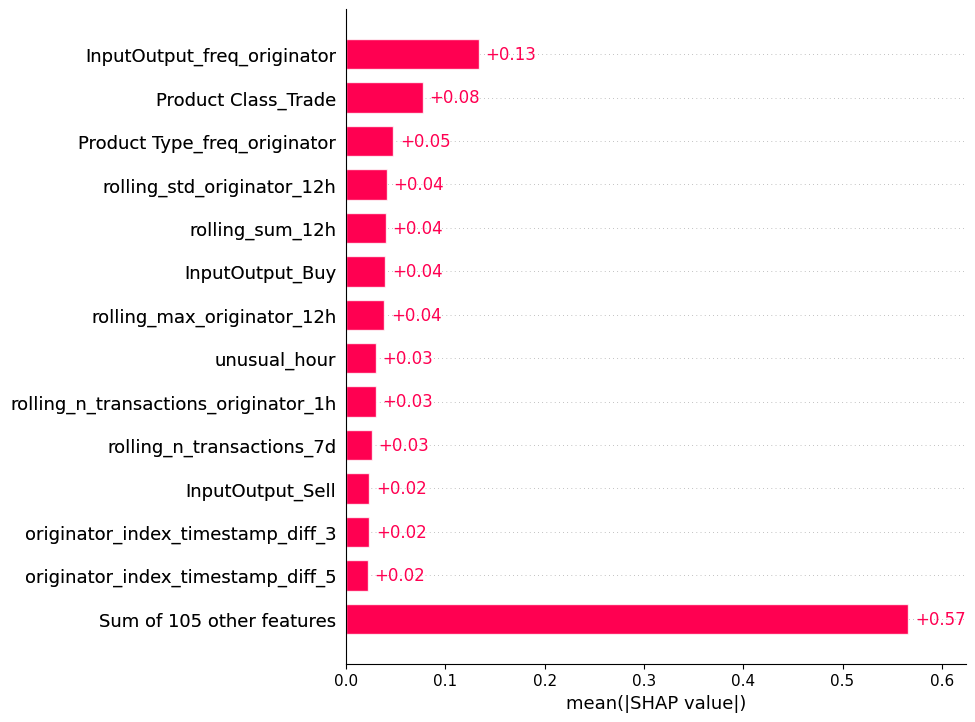

Saved SHAP plots for class 4 to output/shap_plots/
SHAP explanations generated and saved.


In [170]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent_random')


## 4.5. An unusually large amount of collateral transferred in and out of an account within a short period of time:
This behavior is unusual as a client would not be able to invest by simply trading collateral, or at least such a strategy would be unusual.  


In [171]:
idx = 51761 #2762376
#idx = 2762376

anomaly_type = 5


In [172]:
X_train_a = X_train[y_pred_train == anomaly_type]
z_train_a = z_train[y_pred_train == anomaly_type]
y_train_a = y_pred_train[y_pred_train == anomaly_type]
print(X_train_a.shape)
print(z_train_a.shape)
print(y_train_a.shape)

(47246, 118)
(47246, 16)
(47246,)


In [183]:
x = z_test[idx].reshape(1, -1)
print(x.shape)
print(x[:, :6])
print(y_test[idx])
print(y_pred_test[idx])
x

(1, 16)
[[ 0.56476325 -1.5655953  -0.10352112  1.7363416  -2.1745281   0.78480864]]
5
5


array([[ 5.6476325e-01, -1.5655953e+00, -1.0352112e-01,  1.7363416e+00,
        -2.1745281e+00,  7.8480864e-01, -2.3828528e+00, -2.4272187e+00,
         1.9520782e+00,  3.3185631e-04,  2.8013988e+00,  2.4462135e+00,
        -1.9611121e+00,  1.5891352e+00, -2.0886576e+00, -9.2471707e-01]],
      dtype=float32)

In [174]:
df_correct_preds.filter(pl.col("index") == idx)

index,Model Prediction,id,datetime,Originator,Anomaly,Anomaly_bin,amount_log,InputOutput_Buy,InputOutput_Sell,Market_1,Market_2,Market_3,Market_4,Product Type_ADR,Product Type_Bond,Product Type_CAADR,Product Type_ETOEquity,Product Type_ETOEquityIndex,Product Type_Equity,Product Type_FX,Product Type_FXForward,Product Type_FXSwap,Product Type_FutureBond,Product Type_FutureCommodity,Product Type_FutureEquity,Product Type_FutureEquityIndex,Product Type_FutureFX,Product Type_FutureOptionEquityIndex,Product Type_Repo,Product Type_SimpleTransfer,Product Class_ADR Conversion,"Product Class_Cash in / out (withdrawal), Security in / out",Product Class_External fee,Product Class_Trade,Currency_1,Currency_2,day_of_week,day_of_month,hour,minute,is_rounded,originator_index_timestamp_diff_1,originator_index_timestamp_diff_2,originator_index_timestamp_diff_3,originator_index_timestamp_diff_4,originator_index_timestamp_diff_5,market_index_timestamp_diff_1,market_index_timestamp_diff_2,market_index_timestamp_diff_3,market_index_timestamp_diff_4,market_index_timestamp_diff_5,product_type_index_timestamp_diff_1,product_type_index_timestamp_diff_2,product_type_index_timestamp_diff_3,product_type_index_timestamp_diff_4,product_type_index_timestamp_diff_5,product_class_index_timestamp_diff_1,product_class_index_timestamp_diff_2,product_class_index_timestamp_diff_3,product_class_index_timestamp_diff_4,product_class_index_timestamp_diff_5,originator_index_amount_diff_1,market_index_amount_diff_1,product_type_index_amount_diff_1,product_class_index_amount_diff_1,day_of_week_sin,day_of_week_cos,day_of_month_sin,day_of_month_cos,hour_sin,hour_cos,minute_sin,minute_cos,rolling_mean_1h,rolling_mean_12h,rolling_mean_24h,rolling_mean_7d,rolling_sum_1h,rolling_sum_12h,rolling_sum_24h,rolling_sum_7d,rolling_std_1h,rolling_std_12h,rolling_std_24h,rolling_std_7d,rolling_max_1h,rolling_max_12h,rolling_max_24h,rolling_max_7d,rolling_min_1h,rolling_min_12h,rolling_min_24h,rolling_min_7d,rolling_n_transactions_1h,rolling_n_transactions_12h,rolling_n_transactions_24h,rolling_n_transactions_7d,rolling_mean_originator_1h,rolling_mean_originator_12h,rolling_mean_originator_24h,rolling_mean_originator_7d,rolling_std_originator_1h,rolling_std_originator_12h,rolling_std_originator_24h,rolling_std_originator_7d,rolling_max_originator_1h,rolling_max_originator_12h,rolling_max_originator_24h,rolling_max_originator_7d,rolling_min_originator_1h,rolling_min_originator_12h,rolling_min_originator_24h,rolling_min_originator_7d,rolling_sum_originator_1h,rolling_sum_originator_12h,rolling_sum_originator_24h,rolling_sum_originator_7d,rolling_n_transactions_originator_1h,rolling_n_transactions_originator_12h,rolling_n_transactions_originator_24h,rolling_n_transactions_originator_7d,cumcount_InputOutput,cumcount_Market,cumcount_Product Type,cumcount_Product Class,cumcount_Currency,InputOutput_freq_originator,Market_freq_originator,Product Type_freq_originator,Product Class_freq_originator,Currency_freq_originator,unusual_hour
u32,i64,u32,datetime[μs],str,i64,i8,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i8,i8,i8,i8,bool,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,bool
51761,5,27267021,2019-03-18 08:25:02,"""Client_269""",5,1,0.142828,1,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,1,18,8,25,false,2.706623,1.948048,1.612494,1.436176,1.33245,-0.669069,-0.284955,-0.112912,0.0,0.0,0.310631,0.766369,1.71438,1.997665,2.296045,2.411019,-0.183119,-0.071133,0.0,0.0,-0.953268,-0.000208,1.078086,-2.42795,0.71708,1.365456,0.513469,-1.287407,-1.364252,0.64142,-0.831225,-1.144312,0.627442,0.324539,0.360447,-0.903688,0.146866,-1.84126

In [178]:
lasso_x_train, lasso_y_train, _ = find_knn_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)

(42, 118)
(42,)


In [179]:
lasso_classifier = Lasso(alpha=0.01, max_iter=10000)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

Lasso(alpha=0.01, max_iter=10000)

In [180]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 35   9  15 109  19   5  86  73  97 110]
num of non-zero features: 34
originator_index_timestamp_diff_5: 8.703273194102804
Product Type_CAADR: -2.042918523668726
Product Type_FXSwap: 1.6850717200223773
cumcount_Product Type: -1.4682239056270339
Product Type_FutureEquityIndex: 1.4671476222274713
Market_3: 1.4167691291230378
rolling_mean_originator_7d: -1.3552697386725998
rolling_max_24h: -1.231435695168961
rolling_min_originator_24h: -1.1816360076644172
cumcount_Product Class: -0.9611644248567233


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


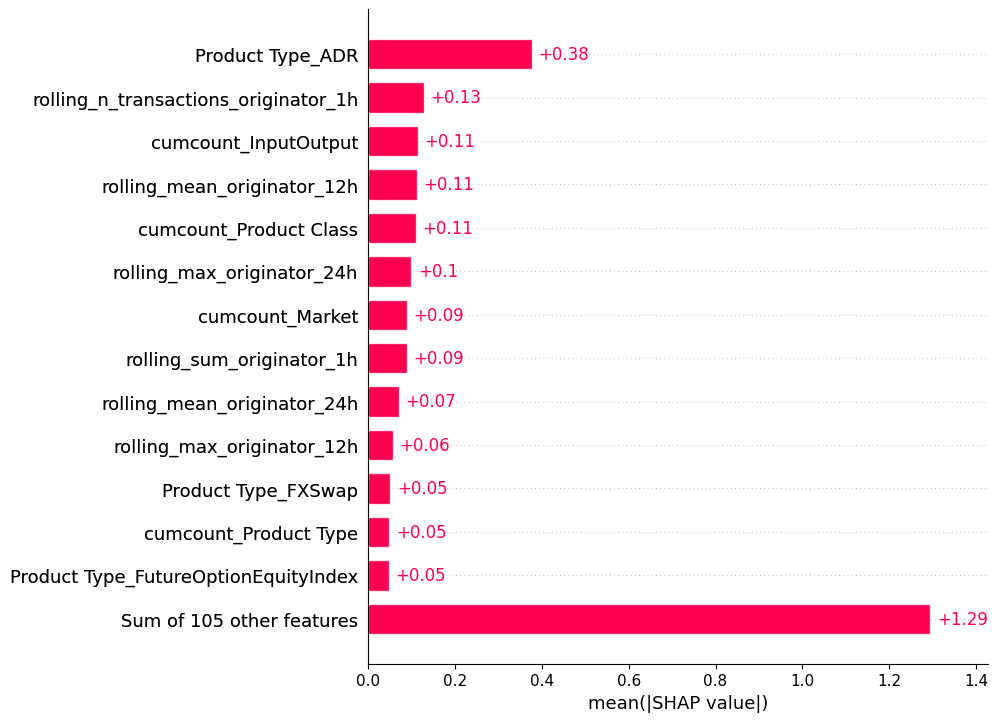

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [181]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent')


In [184]:
# This method chooses normal transactions randomly
lasso_x_train, lasso_y_train, indices_r = select_random_latent(x, X_train_n, z_train_n, y_train_n, X_train_a, z_train_a, y_train_a, k=21)
lasso_classifier = Lasso(alpha=0.01)
lasso_classifier.fit(lasso_x_train, lasso_y_train)
#print(lasso_classifier.coef_)
#print(lasso_classifier.intercept_)

(42, 118)
(42,)


Lasso(alpha=0.01)

In [185]:
sorted_importance = show_importance(lasso_classifier.coef_, feature_names, n_features=10)

[ 25  35  72 115  57  20   1 114  37  12]
num of non-zero features: 35
Product Class_Cash in / out (withdrawal), Security in / out: 2.2322110352108484
originator_index_timestamp_diff_5: 0.8049331475997922
rolling_max_12h: -0.552672270378302
Product Class_freq_originator: -0.4408581924914124
hour_sin: 0.4089985324442837
Product Type_FutureFX: -0.3401631027961303
InputOutput_Buy: 0.33340705323231135
Product Type_freq_originator: 0.3323422955248076
market_index_timestamp_diff_2: 0.2605132379715157
Product Type_Equity: 0.25216017055172635


  0%|          | 0/1 [00:00<?, ?it/s]

SHAP values shape: (1, 118, 6)
5


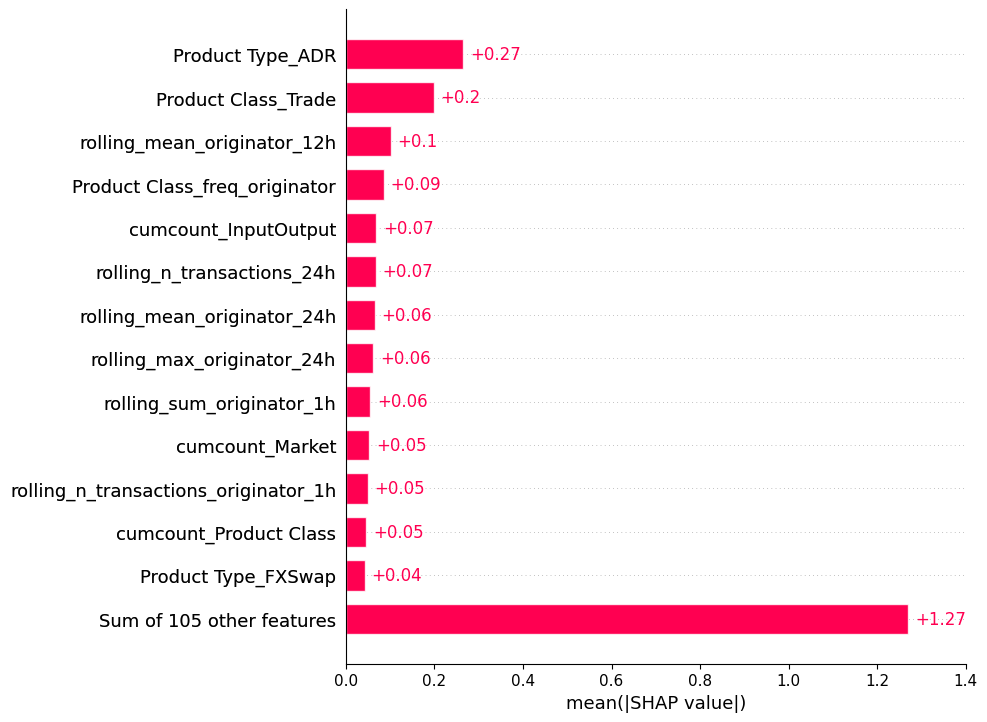

Saved SHAP plots for class 5 to output/shap_plots/
SHAP explanations generated and saved.


In [187]:
x = X_test[idx].reshape(1, -1)
get_shap_explanations_mlp_class(model, lasso_x_train, x, feature_names, filename='figs/shap_plots/shap_amaretto_CM_latent_random')